In [4]:
import pandas as pd

df = pd.read_csv('merged_df12.csv')
df.head()

/tmp/ipykernel_45380/2219044536.py:3: DtypeWarning: Columns (66,69,93) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('merged_df12.csv')


,campaign_id,ad_group_id,customer_id,Date,impressions,clicks,cost_usd,ctr,conversions_Master,cost_per_conversion_usd,...,geographic_report_ctr,geographic_report_cost_usd,geographic_report_conversions,geographic_report_cost_per_conversion,geographic_report_geo_target_constant,bidding_strategy_bidding_strategy_type,bidding_strategy_budget_amount_consumed,bidding_strategy_target_roas,bidding_strategy_target_cpa_micros,Negative_keywords
0,18080181496,1.386540e+11,NaN,2022-08-21,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,TARGET_SPEND,NaN,NaN,NaN,NaN
1,18080181496,1.386540e+11,NaN,2022-08-21,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,TARGET_SPEND,NaN,NaN,NaN,NaN
2,18080181496,1.386540e+11,NaN,2022-08-21,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,TARGET_SPEND,NaN,NaN,NaN,NaN
3,18080181496,1.386540e+11,1.634726e+09,2022-08-22,8.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2840.0,TARGET_SPEND,NaN,NaN,NaN,NaN
4,18080181496,1.386540e+11,1.634726e+09,2022-08-22,8.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2840.0,TARGET_SPEND,NaN,NaN,NaN,NaN


In [5]:
df = df.sample(frac=0.5, random_state=42).reset_index(drop=True)

In [6]:
import pandas as pd

# Calculate the number of NaN values per column
nan_counts = df.isnull().sum()
print("Number of NaN values per column:")
# Set display option to show all rows for the Series
pd.set_option('display.max_rows', None)
# Print all values inside nan_counts
print(nan_counts)
# Reset display option to default (optional)
# pd.reset_option('display.max_rows')


# Display DataFrame info (optional, keep if still desired)
# df.info()

Number of NaN values per column:
campaign_id                                                            0
ad_group_id                                                           60
customer_id                                                        52964
Date                                                                 121
impressions                                                        52964
clicks                                                             52964
cost_usd                                                           52964
ctr                                                                52964
conversions_Master                                                 52964
cost_per_conversion_usd                                            52964
average_cpc_usd                                                    52964
Keyword_Quality_Keyword                                            52684
Keyword_Quality_Estimated_Quality_Score                            52684
Keyword_Quality_KW

In [7]:
# Impute missing 'ad_group_id' values based on the mode of 'ad_group_id' within each 'campaign_id' group
# Handle cases where mode is empty by filling with 0
# Missing 'ad_group_id' values are imputed with the mode of 'ad_group_id' within the same 'campaign_id' group.
df['ad_group_id'] = df.groupby('campaign_id')['ad_group_id'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0))

# Verify the imputation by checking the number of remaining NaN values in 'ad_group_id'
nan_counts_after_imputation = df['ad_group_id'].isnull().sum()
print(f"Number of NaN values in 'ad_group_id' after imputation: {nan_counts_after_imputation}")

Number of NaN values in 'ad_group_id' after imputation: 0


In [8]:
# Impute missing values in the 'Date' column using forward fill (filling with the previous valid date)
df['Date'] = df['Date'].ffill()

# Verify the imputation by checking the number of remaining NaN values in 'Date'
nan_counts_after_date_imputation = df['Date'].isnull().sum()
print(f"Number of NaN values in 'Date' after forward fill imputation: {nan_counts_after_date_imputation}")

Number of NaN values in 'Date' after forward fill imputation: 0


In [111]:
# Impute any remaining missing values in the 'Date' column using backward fill (filling with the next valid date)
df['Date'] = df['Date'].bfill()

# Verify the imputation by checking the number of remaining NaN values in 'Date'
nan_counts_after_bfill_date_imputation = df['Date'].isnull().sum()
print(f"Number of NaN values in 'Date' after backward fill imputation: {nan_counts_after_bfill_date_imputation}")

Number of NaN values in 'Date' after backward fill imputation: 0


In [9]:
# Impute missing 'impressions' values based on the mean of 'impressions' within each group of 'campaign_id', 'ad_group_id', and 'Date'
# Use 0 as a fallback if the mean cannot be calculated for a group
df['impressions'] = df.groupby(['campaign_id', 'ad_group_id', 'Date'])['impressions'].transform(lambda x: x.fillna(x.mean() if not x.isnull().all() else 0))

# Verify the imputation
nan_counts_after_impressions_imputation = df['impressions'].isnull().sum()
print(f"Number of NaN values in 'impressions' after imputation: {nan_counts_after_impressions_imputation}")

Number of NaN values in 'impressions' after imputation: 0


In [10]:
columns_to_impute = ['clicks', 'cost_usd', 'ctr', 'average_cpc_usd']

for column in columns_to_impute:
    # Impute missing values based on the mean within each group
    # Use 0 as a fallback if the mean cannot be calculated for a group
    df[column] = df.groupby(['campaign_id', 'ad_group_id', 'Date'])[column].transform(lambda x: x.fillna(x.mean() if not x.isnull().all() else 0))

    # Verify the imputation
    nan_counts_after_imputation = df[column].isnull().sum()
    print(f"Number of NaN values in '{column}' after imputation: {nan_counts_after_imputation}")

Number of NaN values in 'clicks' after imputation: 0
Number of NaN values in 'cost_usd' after imputation: 0
Number of NaN values in 'ctr' after imputation: 0
Number of NaN values in 'average_cpc_usd' after imputation: 0


In [11]:
import numpy as np

# Identify rows where Impressions, Clicks, and CTR are all 0 AND conversion_rate_Interactions is missing
condition_interactions = (df['impressions'] == 0) & (df['clicks'] == 0) & (df['ctr'] == 0) & (df['conversion_rate_Interactions'].isnull())
# Impute conversion_rate_Interactions with 0 in these rows
df.loc[condition_interactions, 'conversion_rate_Interactions'] = 0

# Identify rows where Impressions, Clicks, and CTR are all 0 AND conversion_rate_Conversions is missing
condition_conversions = (df['impressions'] == 0) & (df['clicks'] == 0) & (df['ctr'] == 0) & (df['conversion_rate_Conversions'].isnull())
# Impute conversion_rate_Conversions with 0 in these rows
df.loc[condition_conversions, 'conversion_rate_Conversions'] = 0

# Verify the imputation by checking the number of remaining NaN values in both columns
nan_counts_after_step1_imputation_interactions = df['conversion_rate_Interactions'].isnull().sum()
nan_counts_after_step1_imputation_conversions = df['conversion_rate_Conversions'].isnull().sum()

print(f"Number of remaining NaN values in 'conversion_rate_Interactions' after step 1: {nan_counts_after_step1_imputation_interactions}")
print(f"Number of remaining NaN values in 'conversion_rate_Conversions' after step 1: {nan_counts_after_step1_imputation_conversions}")

Number of remaining NaN values in 'conversion_rate_Interactions' after step 1: 67068
Number of remaining NaN values in 'conversion_rate_Conversions' after step 1: 67068


In [12]:
# Calculate the mean of non-missing values for 'conversion_rate_Interactions' and 'conversion_rate_Conversions'
mean_interactions = df['conversion_rate_Interactions'].mean()
mean_conversions = df['conversion_rate_Conversions'].mean()

# Impute remaining missing values with the calculated means
df['conversion_rate_Interactions'].fillna(mean_interactions, inplace=True)
df['conversion_rate_Conversions'].fillna(mean_conversions, inplace=True)

# Verify the imputation
nan_counts_after_step2_imputation_interactions = df['conversion_rate_Interactions'].isnull().sum()
nan_counts_after_step2_imputation_conversions = df['conversion_rate_Conversions'].isnull().sum()

print(f"Number of remaining NaN values in 'conversion_rate_Interactions' after step 2: {nan_counts_after_step2_imputation_interactions}")
print(f"Number of remaining NaN values in 'conversion_rate_Conversions' after step 2: {nan_counts_after_step2_imputation_conversions}")

Number of remaining NaN values in 'conversion_rate_Interactions' after step 2: 0
Number of remaining NaN values in 'conversion_rate_Conversions' after step 2: 0


/tmp/ipykernel_45380/1028944290.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['conversion_rate_Interactions'].fillna(mean_interactions, inplace=True)
/tmp/ipykernel_45380/1028944290.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

In [13]:
# Calculate 'conversion_rate_Conversion_rate_(%)' handling division by zero
# If 'conversion_rate_Interactions' is 0, the conversion rate is 0
df['conversion_rate_Conversion_rate_(%)'] = np.where(
    df['conversion_rate_Interactions'] == 0,
    0,
    round((df['conversion_rate_Conversions'] / df['conversion_rate_Interactions']) * 100, 2)
)

# Verify the update by checking the number of remaining NaN values
nan_counts_after_recalculation = df['conversion_rate_Conversion_rate_(%)'].isnull().sum()
print(f"Number of NaN values in 'conversion_rate_Conversion_rate_(%)' after recalculation: {nan_counts_after_recalculation}")

Number of NaN values in 'conversion_rate_Conversion_rate_(%)' after recalculation: 0


In [14]:
# Impute missing values in 'Keyword_Quality_Keyword' using forward fill
df['Keyword_Quality_Keyword'] = df['Keyword_Quality_Keyword'].ffill()

# Verify the imputation
nan_counts_after_keyword_imputation = df['Keyword_Quality_Keyword'].isnull().sum()
print(f"Number of NaN values in 'Keyword_Quality_Keyword' after forward fill imputation: {nan_counts_after_keyword_imputation}")

Number of NaN values in 'Keyword_Quality_Keyword' after forward fill imputation: 0


In [15]:
# Impute any remaining missing values in the 'Keyword_Quality_Keyword' column using backward fill
df['Keyword_Quality_Keyword'] = df['Keyword_Quality_Keyword'].bfill()

# Verify the imputation by checking the number of remaining NaN values in 'Keyword_Quality_Keyword'
nan_counts_after_bfill_keyword_imputation = df['Keyword_Quality_Keyword'].isnull().sum()
print(f"Number of NaN values in 'Keyword_Quality_Keyword' after backward fill imputation: {nan_counts_after_bfill_keyword_imputation}")

Number of NaN values in 'Keyword_Quality_Keyword' after backward fill imputation: 0


# Task
Impute missing values in the 'Keyword_Quality_Estimated_Quality_Score' and 'Keyword_Quality_KW_types' columns of the dataframe based on the 'Keyword_Quality_Keyword' column.

## Group by keyword

### Subtask:
Group the DataFrame by the 'Keyword_Quality_Keyword' column.


**Reasoning**:
Group the DataFrame by the 'Keyword_Quality_Keyword' column as instructed in the subtask.



In [16]:
grouped_by_keyword = df.groupby('Keyword_Quality_Keyword')

## Calculate group imputation values

### Subtask:
Within each keyword group, calculate the mean (or median) of the non-missing 'Keyword_Quality_Estimated_Quality_Score' values and the mode of the non-missing 'Keyword_Quality_KW_types' values.


**Reasoning**:
Calculate the mean of 'Keyword_Quality_Estimated_Quality_Score' and the mode of 'Keyword_Quality_KW_types' within each keyword group.



In [17]:
# Calculate the mean of non-missing 'Keyword_Quality_Estimated_Quality_Score' for each keyword group
mean_quality_score_per_keyword = grouped_by_keyword['Keyword_Quality_Estimated_Quality_Score'].transform(lambda x: x.mean() if not x.isnull().all() else None)

# Calculate the mode of non-missing 'Keyword_Quality_KW_types' for each keyword group, taking the first mode if there are multiple
mode_kw_types_per_keyword = grouped_by_keyword['Keyword_Quality_KW_types'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

## Impute missing values

### Subtask:
Impute the missing 'Keyword_Quality_Estimated_Quality_Score' and 'Keyword_Quality_KW_types' values within each group using the calculated group-specific imputation values.


**Reasoning**:
Impute the missing values in the specified columns using the previously calculated group-specific values.



In [19]:
# Impute missing 'Keyword_Quality_Estimated_Quality_Score' values with the calculated mean per keyword
df['Keyword_Quality_Estimated_Quality_Score'] = df['Keyword_Quality_Estimated_Quality_Score'].fillna(mean_quality_score_per_keyword)

# Impute missing 'Keyword_Quality_KW_types' values with the calculated mode per keyword
df['Keyword_Quality_KW_types'] = df['Keyword_Quality_KW_types'].fillna(mode_kw_types_per_keyword)

# Verify the imputation by checking the number of remaining NaN values
nan_counts_after_imputation_quality_score = df['Keyword_Quality_Estimated_Quality_Score'].isnull().sum()
nan_counts_after_imputation_kw_types = df['Keyword_Quality_KW_types'].isnull().sum()

print(f"Number of NaN values in 'Keyword_Quality_Estimated_Quality_Score' after imputation: {nan_counts_after_imputation_quality_score}")
print(f"Number of NaN values in 'Keyword_Quality_KW_types' after imputation: {nan_counts_after_imputation_kw_types}")

Number of NaN values in 'Keyword_Quality_Estimated_Quality_Score' after imputation: 0
Number of NaN values in 'Keyword_Quality_KW_types' after imputation: 0


## Summary:

### Data Analysis Key Findings

*   Missing values in the 'Keyword\_Quality\_Estimated\_Quality\_Score' column were imputed using the mean of non-missing values within each 'Keyword\_Quality\_Keyword' group.
*   Missing values in the 'Keyword\_Quality\_KW\_types' column were imputed using the mode of non-missing values within each 'Keyword\_Quality\_Keyword' group.
*   After the imputation process, there are 0 remaining missing values in both the 'Keyword\_Quality\_Estimated\_Quality\_Score' and 'Keyword\_Quality\_KW\_types' columns.

### Insights or Next Steps

*   The imputation strategy successfully addressed the missing data in the specified columns by leveraging the group structure defined by the 'Keyword\_Quality\_Keyword' column.
*   The dataset is now ready for further analysis or modeling without the issue of missing values in these two columns.


In [20]:
import pandas as pd

# Calculate the number of NaN values per column
nan_counts = df.isnull().sum()
print("Number of NaN values per column:")
# Set display option to show all rows for the Series
pd.set_option('display.max_rows', None)
# Print all values inside nan_counts
print(nan_counts)
# Reset display option to default (optional)
# pd.reset_option('display.max_rows')


# Display DataFrame info (optional, keep if still desired)
# df.info()

Number of NaN values per column:
campaign_id                                                            0
ad_group_id                                                            0
customer_id                                                        52964
Date                                                                   0
impressions                                                            0
clicks                                                                 0
cost_usd                                                               0
ctr                                                                    0
conversions_Master                                                 52964
cost_per_conversion_usd                                            52964
average_cpc_usd                                                        0
Keyword_Quality_Keyword                                                0
Keyword_Quality_Estimated_Quality_Score                                0
Keyword_Quality_KW

## Impute missing values in `ad_performance_Impressions` with random sampling

### Subtask:
Impute the missing values in the `ad_performance_Impressions` column with randomly selected non-missing values from the same column.

**Reasoning**:
Impute the missing values in the `ad_performance_Impressions` column by randomly sampling from the existing non-missing values in that column.

In [21]:
import numpy as np
import pandas as pd

# Get non-missing values from 'ad_performance_Impressions'
non_missing_impressions = df['ad_performance_Impressions'].dropna()

# Calculate the number of missing values remaining in 'ad_performance_Impressions'
num_missing = df['ad_performance_Impressions'].isnull().sum()

# Check if there are enough non-missing values to sample from
if len(non_missing_impressions) > 0:
    # Impute missing values with random samples from non-missing values
    # Ensure the size of the sample matches the number of missing values
    df.loc[df['ad_performance_Impressions'].isnull(), 'ad_performance_Impressions'] = np.random.choice(non_missing_impressions, size=num_missing)
else:
    print("Cannot perform random imputation as there are no non-missing values to sample from.")


# Verify the imputation
nan_counts_after_impressions_random_imputation = df['ad_performance_Impressions'].isnull().sum()
print(f"Number of NaN values in 'ad_performance_Impressions' after random imputation: {nan_counts_after_impressions_random_imputation}")

Number of NaN values in 'ad_performance_Impressions' after random imputation: 0


## Impute missing values in remaining `ad_performance_` columns with random sampling

### Subtask:
Identify the remaining columns in the `ad_performance_` group with missing values and impute them using random sampling from their respective non-missing values.

**Reasoning**:
Iterate through the remaining `ad_performance_` columns with missing values and apply the random sampling imputation strategy to each.

In [22]:
import pandas as pd

# Calculate the number of NaN values per column
nan_counts = df.isnull().sum()
print("Number of NaN values per column:")
# Set display option to show all rows for the Series
pd.set_option('display.max_rows', None)
# Print all values inside nan_counts
print(nan_counts)
# Reset display option to default (optional)
# pd.reset_option('display.max_rows')


# Display DataFrame info (optional, keep if still desired)
# df.info()

Number of NaN values per column:
campaign_id                                                            0
ad_group_id                                                            0
customer_id                                                        52964
Date                                                                   0
impressions                                                            0
clicks                                                                 0
cost_usd                                                               0
ctr                                                                    0
conversions_Master                                                 52964
cost_per_conversion_usd                                            52964
average_cpc_usd                                                        0
Keyword_Quality_Keyword                                                0
Keyword_Quality_Estimated_Quality_Score                                0
Keyword_Quality_KW

## Drop columns with a high number of missing values

### Subtask:
Drop the columns `bidding_strategy_budget_amount_consumed`, `bidding_strategy_target_roas`, and `bidding_strategy_target_cpa_micros` from the DataFrame.

**Reasoning**:
Drop the specified columns from the DataFrame as they contain a very high number of missing values, making imputation or retention impractical.

In [23]:
# Drop the specified columns
columns_to_drop = [
    'bidding_strategy_budget_amount_consumed',
    'bidding_strategy_target_roas',
    'bidding_strategy_target_cpa_micros'
]

# Get the columns that actually exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_columns_to_drop:
    df.drop(columns=existing_columns_to_drop, inplace=True)
    print("DataFrame after dropping columns:")
    display(df.head())

    # Verify the number of NaN values again to see the effect of dropping these columns
    nan_counts_after_dropping = df.isnull().sum()
    print("\nNumber of NaN values per column after dropping:")
    display(nan_counts_after_dropping)
else:
    print("None of the specified columns were found in the DataFrame.")

DataFrame after dropping columns:


,campaign_id,ad_group_id,customer_id,Date,impressions,clicks,cost_usd,ctr,conversions_Master,cost_per_conversion_usd,...,search_term_conversions,geographic_report_impressions,geographic_report_clicks,geographic_report_ctr,geographic_report_cost_usd,geographic_report_conversions,geographic_report_cost_per_conversion,geographic_report_geo_target_constant,bidding_strategy_bidding_strategy_type,Negative_keywords
0,22055555180,1.698395e+11,1.634726e+09,2025-01-21,210.0,6.0,2649.144718,0.028571,0.0,0.0,...,0.0,210.0,6.0,0.028571,2649.144718,0.0,0.0,NaN,MAXIMIZE_CONVERSIONS,"['advertising network', 'social media agencies..."
1,20500248675,1.581894e+11,1.634726e+09,2023-10-17,4.0,2.0,766.150000,0.500000,0.0,0.0,...,0.0,4.0,2.0,0.500000,766.150000,0.0,0.0,2840.0,TARGET_SPEND,"['tool', 'software', 'seo', 'com', 'Free', 'ma..."
2,18080181496,1.389721e+11,1.634726e+09,2022-08-23,123.0,2.0,261.980000,0.016260,0.0,0.0,...,0.0,46.0,2.0,0.043478,261.980000,0.0,0.0,2840.0,TARGET_SPEND,NaN
3,22055555180,1.698395e+11,1.634726e+09,2025-01-21,210.0,6.0,2649.144718,0.028571,0.0,0.0,...,0.0,210.0,6.0,0.028571,2649.144718,0.0,0.0,NaN,MAXIMIZE_CONVERSIONS,"['advertising network', 'social media agencies..."
4,22503584851,1.766835e+11,1.634726e+09,2025-07-10,172.0,6.0,1998.968460,0.034884,0.0,0.0,...,0.0,100.0,4.0,0.040000,1140.710000,0.0,0.0,2840.0,TARGET_SPEND,NaN



Number of NaN values per column after dropping:


campaign_id                                                            0
ad_group_id                                                            0
customer_id                                                        52964
Date                                                                   0
impressions                                                            0
clicks                                                                 0
cost_usd                                                               0
ctr                                                                    0
conversions_Master                                                 52964
cost_per_conversion_usd                                            52964
average_cpc_usd                                                        0
Keyword_Quality_Keyword                                                0
Keyword_Quality_Estimated_Quality_Score                                0
Keyword_Quality_KW_types                           

## Apply random sampling imputation to all columns with missing values

### Subtask:
Identify all columns in the DataFrame with missing values and impute them using random sampling from their respective non-missing values.

**Reasoning**:
Iterate through all columns with missing values and apply the random sampling imputation strategy to each, as requested by the user.

In [24]:
import numpy as np
import pandas as pd

# Identify all columns in the DataFrame with missing values
columns_to_impute_all = df.columns[df.isnull().any()].tolist()

print(f"Columns to impute using random sampling: {columns_to_impute_all}")

for column in columns_to_impute_all:
    print(f"\nProcessing column: {column}")
    # Get non-missing values from the current column
    non_missing_values = df[column].dropna()

    # Calculate the number of missing values remaining in the current column
    num_missing = df[column].isnull().sum()

    # Check if there are enough non-missing values to sample from
    if len(non_missing_values) > 0:
        # Impute missing values with random samples from non-missing values
        # Ensure the size of the sample matches the number of missing values
        df.loc[df[column].isnull(), column] = np.random.choice(non_missing_values, size=num_missing)
        print(f"Successfully imputed {column} with random sampling.")
    else:
        print(f"Cannot perform random imputation for {column} as there are no non-missing values to sample from.")

    # Verify the imputation
    nan_counts_after_imputation = df[column].isnull().sum()
    print(f"Number of NaN values in '{column}' after imputation: {nan_counts_after_imputation}")

# Final verification of NaN counts across all columns
print("\nFinal number of NaN values per column after processing all columns:")
display(df.isnull().sum())

Columns to impute using random sampling: ['customer_id', 'conversions_Master', 'cost_per_conversion_usd', 'ad_performance_Clicks', 'ad_performance_Cost_(USD)', 'ad_performance_CTR', 'ad_performance_Avg._CPC', 'ad_performance_Cost_per_Acquisition', 'ad_performance_Interactions', 'ad_performance_Conversions', 'ad_performance_Conversion_Rate_(%)', 'ad_performance_Search_Abs._Top_Impression_Share', 'ad_performance_Search_Top_Impression_Share', 'ad_performance_Search_Impression_Share', 'ad_performance_Search_Rank_Lost_Imp._Share', 'Device_performance_Device', 'Device_performance_Impressions', 'Device_performance_Clicks', 'Device_performance_CTR', 'Device_performance_Cost_USD', 'Device_performance_Conversions', 'Device_performance_Cost_per_Conversion', 'Device_performance_Search_Abs_Top_Impression_Share', 'Device_performance_Search_Budget_Lost_Abs_Top_Impression_Share', 'Device_performance_Search_Budget_Lost_Top_Impression_Share', 'Device_performance_Search_Top_Impression_Share', 'Device_per

campaign_id                                                       0
ad_group_id                                                       0
customer_id                                                       0
Date                                                              0
impressions                                                       0
clicks                                                            0
cost_usd                                                          0
ctr                                                               0
conversions_Master                                                0
cost_per_conversion_usd                                           0
average_cpc_usd                                                   0
Keyword_Quality_Keyword                                           0
Keyword_Quality_Estimated_Quality_Score                           0
Keyword_Quality_KW_types                                          0
conversion_rate_Interactions                    

In [25]:
pd.set_option('display.max_columns', None)
df.head(10)

,campaign_id,ad_group_id,customer_id,Date,impressions,clicks,cost_usd,ctr,conversions_Master,cost_per_conversion_usd,average_cpc_usd,Keyword_Quality_Keyword,Keyword_Quality_Estimated_Quality_Score,Keyword_Quality_KW_types,conversion_rate_Interactions,conversion_rate_Conversions,conversion_rate_Conversion_rate_(%),ad_performance_Impressions,ad_performance_Clicks,ad_performance_Cost_(USD),ad_performance_CTR,ad_performance_Avg._CPC,ad_performance_Cost_per_Acquisition,ad_performance_Interactions,ad_performance_Conversions,ad_performance_Conversion_Rate_(%),ad_performance_Search_Abs._Top_Impression_Share,ad_performance_Search_Top_Impression_Share,ad_performance_Search_Impression_Share,ad_performance_Search_Rank_Lost_Imp._Share,Device_performance_Device,Device_performance_Impressions,Device_performance_Clicks,Device_performance_CTR,Device_performance_Cost_USD,Device_performance_Conversions,Device_performance_Cost_per_Conversion,Device_performance_Search_Abs_Top_Impression_Share,Device_performance_Search_Budget_Lost_Abs_Top_Impression_Share,Device_performance_Search_Budget_Lost_Top_Impression_Share,Device_performance_Search_Top_Impression_Share,Device_performance_Search_Rank_Lost_Impression_Share,Device_performance_Search_Rank_Lost_Abs_Top_Impression_Share,Device_performance_Search_Rank_Lost_Top_Impression_Share,Device_performance_Search_Impression_Share,Device_performance_Search_Exact_Match_Impression_Share,Keyword_performance_Keyword_Text,Keyword_performance_Keyword_Match_Type,Keyword_performance_impressions,Keyword_performance_clicks,Keyword_performance_CTR,Keyword_performance_average_cpc,Keyword_performance_conversions,Keyword_performance_cost_usd,Keyword_performance_cost_per_conversion,Keyword_performance_search_impression_share,Keyword_performance_search_top_impression_share,Keyword_performance_search_absolute_top_impression_share,Keyword_performance_search_rank_lost_impression_share,Keyword_performance_absolute_top_impression_percentage,Keyword_performance_top_impression_percentage,Keyword_performance_estimated_first_position_cpc,Keyword_performance_search_exact_match_impression_share,bid_Adjustments_bid_modifier,bid_Adjustments_device_type,bid_Adjustments_device_type_name,resource_name,ad_schedule_start_hour,ad_schedule_end_hour,day_of_week,ad_schedule_impressions,ad_schedule_clicks,ad_schedule_cost_usd,ad_schedule_conversions,keywords_meta_keyword_text,keywords_meta_match_type,keywords_meta_quality_score,search_term_search_term,search_term_impressions,search_term_clicks,search_term_cost_usd,search_term_conversions,geographic_report_impressions,geographic_report_clicks,geographic_report_ctr,geographic_report_cost_usd,geographic_report_conversions,geographic_report_cost_per_conversion,geographic_report_geo_target_constant,bidding_strategy_bidding_strategy_type,Negative_keywords
0,22055555180,1.698395e+11,1.634726e+09,2025-01-21,210.0,6.0,2649.144718,0.028571,0.0,0.0,441.524120,online marketing company,0.0,4.0,6.000000,0.000000,0.00,210.0,6.0,2649.144718,0.028571,4.415241e+08,0.0,6.0,0.0,0.0,0.0999,0.0999,0.0999,0.900100,TABLET,3.0,0.0,0.000000,0.000000,0.0,0.0,0.0999,0.000000,0.000000,0.0999,0.900100,0.900100,0.900100,0.0999,0.099900,online marketing company,PHRASE,0.0,0.0,0.000000,0.0,0.0,0.00,0.0,0.099900,0.0999,0.0999,0.900100,0.000000,0.000000,0.0,0.000000,0.0,3.0,TABLET,customers/1634725968/adScheduleViews/220555551...,0.0,9.0,TUESDAY,179.0,6.0,2649.144718,0.0,online marketing company,BROAD,0.0,smma business,1.0,0.0,0.0,0.0,210.0,6.0,0.028571,2649.144718,0.0,0.0,2840.0,MAXIMIZE_CONVERSIONS,"['advertising network', 'social media agencies..."
1,20500248675,1.581894e+11,1.634726e+09,2023-10-17,4.0,2.0,766.150000,0.500000,0.0,0.0,383.075000,seo agency,0.0,3.0,2.000000,0.000000,0.00,4.0,2.0,766.150000,0.500000,3.830750e+08,0.0,2.0,0.0,0.0,0.0999,0.0999,0.0999,0.016017,MOBILE,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0999,0.900100,0.900100,0.0999,0.016405,0.016405,0.016405,0.0999,0.099900,seo agency,PHRASE,0.0,0.0,0.000000,0.0,0.0,0.

In [26]:
# ... existing code ...
unique_df = df.drop_duplicates()
unique_df.info()
# ... existing code ...

<class 'pandas.core.frame.DataFrame'>
Index: 384017 entries, 0 to 385951
Data columns (total 91 columns):
 #   Column                                                          Non-Null Count   Dtype  
---  ------                                                          --------------   -----  
 0   campaign_id                                                     384017 non-null  int64  
 1   ad_group_id                                                     384017 non-null  float64
 2   customer_id                                                     384017 non-null  float64
 3   Date                                                            384017 non-null  object 
 4   impressions                                                     384017 non-null  float64
 5   clicks                                                          384017 non-null  float64
 6   cost_usd                                                        384017 non-null  float64
 7   ctr                                        

In [27]:
df = unique_df

In [28]:
df.shape

(384017, 91)

In [29]:
categorical_columns = [
    'Keyword_Quality_Keyword',
    'Keyword_Quality_KW_types',
    'Device_performance_Device',
    'Keyword_performance_Keyword_Text',
    'Keyword_performance_Keyword_Match_Type',
    'bid_Adjustments_device_type',
    'bid_Adjustments_device_type_name',
    'resource_name',
    'day_of_week',
    'keywords_meta_keyword_text',
    'keywords_meta_match_type',
    'search_term_search_term',
    'bidding_strategy_bidding_strategy_type',
    'Negative_keywords',
    'geographic_report_geo_target_constant'
]

df_categorical = df[categorical_columns]

print("Categorical DataFrame created:")
display(df_categorical.head())

Categorical DataFrame created:


,Keyword_Quality_Keyword,Keyword_Quality_KW_types,Device_performance_Device,Keyword_performance_Keyword_Text,Keyword_performance_Keyword_Match_Type,bid_Adjustments_device_type,bid_Adjustments_device_type_name,resource_name,day_of_week,keywords_meta_keyword_text,keywords_meta_match_type,search_term_search_term,bidding_strategy_bidding_strategy_type,Negative_keywords,geographic_report_geo_target_constant
0,online marketing company,4.0,TABLET,online marketing company,PHRASE,3.0,TABLET,customers/1634725968/adScheduleViews/220555551...,TUESDAY,online marketing company,BROAD,smma business,MAXIMIZE_CONVERSIONS,"['advertising network', 'social media agencies...",2840.0
1,seo agency,3.0,MOBILE,seo agency,PHRASE,3.0,TABLET,customers/1634725968/adScheduleViews/205002486...,TUESDAY,seo agency,PHRASE,check seo page,TARGET_SPEND,"['tool', 'software', 'seo', 'com', 'Free', 'ma...",2840.0
2,advertising firm,4.0,DESKTOP,advertising firm,BROAD,3.0,TABLET,customers/1634725968/adScheduleViews/220555551...,MONDAY,advertising firm,BROAD,agencia de diseño grafico tijuana,TARGET_SPEND,"['advertising network', 'social media agencies...",2840.0
3,digital marketing advertising companies,4.0,MOBILE,digital marketing advertising companies,PHRASE,2.0,MOBILE,customers/1634725968/adScheduleViews/220555551...,TUESDAY,digital marketing advertising companies,BROAD,what services does a marketing agency provide,MAXIMIZE_CONVERSIONS,"['advertising network', 'social media agencies...",2840.0
4,medical billing and coding companies,2.0,MOBILE,medical billing and coding companies,EXACT,2.0,MOBILE,customers/1634725968/adScheduleViews/220555551...,TUESDAY,medical billing and coding companies,EXACT,medical coding company,TARGET_SPEND,"['tool', 'software', 'seo', 'com', 'Free', 'ma...",2840.0


In [30]:
# Identify non-categorical columns
all_columns = df.columns.tolist()
non_categorical_columns = [col for col in all_columns if col not in categorical_columns]

df_non_categorical = df[non_categorical_columns]

print("Non-categorical DataFrame created:")
display(df_non_categorical.head())

Non-categorical DataFrame created:


,campaign_id,ad_group_id,customer_id,Date,impressions,clicks,cost_usd,ctr,conversions_Master,cost_per_conversion_usd,average_cpc_usd,Keyword_Quality_Estimated_Quality_Score,conversion_rate_Interactions,conversion_rate_Conversions,conversion_rate_Conversion_rate_(%),ad_performance_Impressions,ad_performance_Clicks,ad_performance_Cost_(USD),ad_performance_CTR,ad_performance_Avg._CPC,ad_performance_Cost_per_Acquisition,ad_performance_Interactions,ad_performance_Conversions,ad_performance_Conversion_Rate_(%),ad_performance_Search_Abs._Top_Impression_Share,ad_performance_Search_Top_Impression_Share,ad_performance_Search_Impression_Share,ad_performance_Search_Rank_Lost_Imp._Share,Device_performance_Impressions,Device_performance_Clicks,Device_performance_CTR,Device_performance_Cost_USD,Device_performance_Conversions,Device_performance_Cost_per_Conversion,Device_performance_Search_Abs_Top_Impression_Share,Device_performance_Search_Budget_Lost_Abs_Top_Impression_Share,Device_performance_Search_Budget_Lost_Top_Impression_Share,Device_performance_Search_Top_Impression_Share,Device_performance_Search_Rank_Lost_Impression_Share,Device_performance_Search_Rank_Lost_Abs_Top_Impression_Share,Device_performance_Search_Rank_Lost_Top_Impression_Share,Device_performance_Search_Impression_Share,Device_performance_Search_Exact_Match_Impression_Share,Keyword_performance_impressions,Keyword_performance_clicks,Keyword_performance_CTR,Keyword_performance_average_cpc,Keyword_performance_conversions,Keyword_performance_cost_usd,Keyword_performance_cost_per_conversion,Keyword_performance_search_impression_share,Keyword_performance_search_top_impression_share,Keyword_performance_search_absolute_top_impression_share,Keyword_performance_search_rank_lost_impression_share,Keyword_performance_absolute_top_impression_percentage,Keyword_performance_top_impression_percentage,Keyword_performance_estimated_first_position_cpc,Keyword_performance_search_exact_match_impression_share,bid_Adjustments_bid_modifier,ad_schedule_start_hour,ad_schedule_end_hour,ad_schedule_impressions,ad_schedule_clicks,ad_schedule_cost_usd,ad_schedule_conversions,keywords_meta_quality_score,search_term_impressions,search_term_clicks,search_term_cost_usd,search_term_conversions,geographic_report_impressions,geographic_report_clicks,geographic_report_ctr,geographic_report_cost_usd,geographic_report_conversions,geographic_report_cost_per_conversion
0,22055555180,1.698395e+11,1.634726e+09,2025-01-21,210.0,6.0,2649.144718,0.028571,0.0,0.0,441.52412,0.0,6.0,0.0,0.0,210.0,6.0,2649.144718,0.028571,4.415241e+08,0.0,6.0,0.0,0.0,0.0999,0.0999,0.0999,0.900100,3.0,0.0,0.000000,0.000000,0.0,0.0,0.0999,0.000000,0.000000,0.0999,0.900100,0.900100,0.900100,0.0999,0.0999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.099900,0.0999,0.0999,0.900100,0.000000,0.000000,0.0,0.000000,0.0,0.0,9.0,179.0,6.0,2649.144718,0.0,0.0,1.0,0.0,0.0,0.0,210.0,6.0,0.028571,2649.144718,0.0,0.0
1,20500248675,1.581894e+11,1.634726e+09,2023-10-17,4.0,2.0,766.150000,0.500000,0.0,0.0,383.07500,0.0,2.0,0.0,0.0,4.0,2.0,766.150000,0.500000,3.830750e+08,0.0,2.0,0.0,0.0,0.0999,0.0999,0.0999,0.016017,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0999,0.900100,0.900100,0.0999,0.016405,0.016405,0.016405,0.0999,0.0999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.099900,0.0999,0.0999,0.019231,0.000000,0.000000,0.0,0.099900,0.0,0.0,5.0,4.0,2.0,766.150000,0.0,0.0,1.0,0.0,0.0,0.0,4.0,2.0,0.500000,766.150000,0.0,0.0
2,18080181496,1.389721e+11,1.634726e+09,2022-08-23,123.0,2.0,261.980000,0.016260,0.0,0.0,130.99000,0.0,2.0,0.0,0.0,123.0,2.0,261.980000,0.016260,1.309900e+08,0.0,2.0,0.0,0.0,0.0999,0.0999,0.0999,0.015011,123.0,2.0,0.016260,261.980000,0.0,0.0,0.0999,0.900100,0.900100,0.0999,0.015011,0.021167,0.016698,0.0999,0.0999,33.0,0.0,0.0,0.0,0.0,0.0,0.0,0.099900,0.0999,0.0999,0.016819,0.217391,0.652174,0.0,0.000000,0.0,18.0,9.0,31.0,0.0,1589.760000,0.0,0.0,1.0,0.0,0.0,0.0,46.0,2.0,0.043478,261.980000,0.0,0.0
3,22055555180,1.698395e+11,1.634726e+09,2025-01-21,210.0,6.0,2649.144718,0.028571,0.

In [31]:
# Calculate and display the number of unique values for each categorical column
print("Number of unique values for each categorical column:")
for col in categorical_columns:
    unique_count = df[col].nunique()
    print(f"'{col}': {unique_count}")

Number of unique values for each categorical column:
'Keyword_Quality_Keyword': 180
'Keyword_Quality_KW_types': 3
'Device_performance_Device': 4
'Keyword_performance_Keyword_Text': 310
'Keyword_performance_Keyword_Match_Type': 3
'bid_Adjustments_device_type': 3
'bid_Adjustments_device_type_name': 3
'resource_name': 46
'day_of_week': 6
'keywords_meta_keyword_text': 180
'keywords_meta_match_type': 3
'search_term_search_term': 2986
'bidding_strategy_bidding_strategy_type': 2
'Negative_keywords': 4
'geographic_report_geo_target_constant': 42


In [32]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Define high and low cardinality columns based on the user's request and previous analysis
high_cardinality_cols = [
    'Keyword_Quality_Keyword',
    'Keyword_performance_Keyword_Text',
    'resource_name',
    'keywords_meta_keyword_text',
    'search_term_search_term',
    'Negative_keywords',
    'geographic_report_geo_target_constant'
]

# Identify all categorical columns that are not high cardinality text columns
low_cardinality_cols = [col for col in categorical_columns if col not in high_cardinality_cols]

# Create a copy of the categorical DataFrame to avoid modifying the original
df_encoded = df_categorical.copy()

# Apply Label Encoding to high cardinality columns
for col in high_cardinality_cols:
    if col in df_encoded.columns:
        le = LabelEncoder()
        # Convert to string to handle potential mixed types before encoding
        df_encoded[f'{col}_encoded'] = le.fit_transform(df_encoded[col].astype(str))
        print(f"Applied Label Encoding to '{col}'")
        # Drop the original high cardinality column
        df_encoded.drop(columns=[col], inplace=True)
    else:
        print(f"High cardinality column '{col}' not found in df_encoded.")


# Apply One-Hot Encoding to low cardinality columns
if low_cardinality_cols:
    df_encoded = pd.get_dummies(df_encoded, columns=low_cardinality_cols, prefix=low_cardinality_cols)
    print("\nLow cardinality columns encoded using One-Hot Encoding.")
else:
    print("\nNo low cardinality columns to One-Hot Encode.")


print("\nDataFrame after applying Label Encoding and One-Hot Encoding:")
display(df_encoded.head())

print("\nColumns in the encoded DataFrame:")
print(df_encoded.columns.tolist())

Applied Label Encoding to 'Keyword_Quality_Keyword'
Applied Label Encoding to 'Keyword_performance_Keyword_Text'
Applied Label Encoding to 'resource_name'
Applied Label Encoding to 'keywords_meta_keyword_text'
Applied Label Encoding to 'search_term_search_term'
Applied Label Encoding to 'Negative_keywords'
Applied Label Encoding to 'geographic_report_geo_target_constant'

Low cardinality columns encoded using One-Hot Encoding.

DataFrame after applying Label Encoding and One-Hot Encoding:


,Keyword_Quality_Keyword_encoded,Keyword_performance_Keyword_Text_encoded,resource_name_encoded,keywords_meta_keyword_text_encoded,search_term_search_term_encoded,Negative_keywords_encoded,geographic_report_geo_target_constant_encoded,Keyword_Quality_KW_types_2.0,Keyword_Quality_KW_types_3.0,Keyword_Quality_KW_types_4.0,Device_performance_Device_CONNECTED_TV,Device_performance_Device_DESKTOP,Device_performance_Device_MOBILE,Device_performance_Device_TABLET,Keyword_performance_Keyword_Match_Type_BROAD,Keyword_performance_Keyword_Match_Type_EXACT,Keyword_performance_Keyword_Match_Type_PHRASE,bid_Adjustments_device_type_2.0,bid_Adjustments_device_type_3.0,bid_Adjustments_device_type_4.0,bid_Adjustments_device_type_name_DESKTOP,bid_Adjustments_device_type_name_MOBILE,bid_Adjustments_device_type_name_TABLET,day_of_week_FRIDAY,day_of_week_MONDAY,day_of_week_SATURDAY,day_of_week_THURSDAY,day_of_week_TUESDAY,day_of_week_WEDNESDAY,keywords_meta_match_type_BROAD,keywords_meta_match_type_EXACT,keywords_meta_match_type_PHRASE,bidding_strategy_bidding_strategy_type_MAXIMIZE_CONVERSIONS,bidding_strategy_bidding_strategy_type_TARGET_SPEND
0,104,191,27,104,2472,0,41,False,False,True,False,False,False,True,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False,True,False,False,True,False
1,126,224,16,126,405,3,41,False,True,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True
2,5,13,27,5,105,0,41,False,False,True,False,True,False,False,True,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,True
3,37,77,28,37,2899,0,41,False,False,True,False,False,True,False,False,False,True,True,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False
4,85,161,29,85,1730,3,41,True,False,False,False,False,True,False,False,True,False,True,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,True



Columns in the encoded DataFrame:
['Keyword_Quality_Keyword_encoded', 'Keyword_performance_Keyword_Text_encoded', 'resource_name_encoded', 'keywords_meta_keyword_text_encoded', 'search_term_search_term_encoded', 'Negative_keywords_encoded', 'geographic_report_geo_target_constant_encoded', 'Keyword_Quality_KW_types_2.0', 'Keyword_Quality_KW_types_3.0', 'Keyword_Quality_KW_types_4.0', 'Device_performance_Device_CONNECTED_TV', 'Device_performance_Device_DESKTOP', 'Device_performance_Device_MOBILE', 'Device_performance_Device_TABLET', 'Keyword_performance_Keyword_Match_Type_BROAD', 'Keyword_performance_Keyword_Match_Type_EXACT', 'Keyword_performance_Keyword_Match_Type_PHRASE', 'bid_Adjustments_device_type_2.0', 'bid_Adjustments_device_type_3.0', 'bid_Adjustments_device_type_4.0', 'bid_Adjustments_device_type_name_DESKTOP', 'bid_Adjustments_device_type_name_MOBILE', 'bid_Adjustments_device_type_name_TABLET', 'day_of_week_FRIDAY', 'day_of_week_MONDAY', 'day_of_week_SATURDAY', 'day_of_week_T

In [33]:
df_encoded.columns

Index(['Keyword_Quality_Keyword_encoded',
       'Keyword_performance_Keyword_Text_encoded', 'resource_name_encoded',
       'keywords_meta_keyword_text_encoded', 'search_term_search_term_encoded',
       'Negative_keywords_encoded',
       'geographic_report_geo_target_constant_encoded',
       'Keyword_Quality_KW_types_2.0', 'Keyword_Quality_KW_types_3.0',
       'Keyword_Quality_KW_types_4.0',
       'Device_performance_Device_CONNECTED_TV',
       'Device_performance_Device_DESKTOP', 'Device_performance_Device_MOBILE',
       'Device_performance_Device_TABLET',
       'Keyword_performance_Keyword_Match_Type_BROAD',
       'Keyword_performance_Keyword_Match_Type_EXACT',
       'Keyword_performance_Keyword_Match_Type_PHRASE',
       'bid_Adjustments_device_type_2.0', 'bid_Adjustments_device_type_3.0',
       'bid_Adjustments_device_type_4.0',
       'bid_Adjustments_device_type_name_DESKTOP',
       'bid_Adjustments_device_type_name_MOBILE',
       'bid_Adjustments_device_type_name_T

In [34]:
# Select the specific columns from the original DataFrame 'df'
# These columns were dropped from df_non_categorical in a previous step,
# so we need to select them from the original df before any columns were removed.
df_date_camp_ad = df_non_categorical[['Date', 'campaign_id', 'ad_group_id','customer_id']]
df_non_categorical = df_non_categorical.drop(columns=['Date', 'campaign_id', 'ad_group_id','customer_id'])
# df_date_camp_ad.head

In [35]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Assuming df_date_camp_ad is already created with 'Date', 'campaign_id', and 'ad_group_id'

# Apply Label Encoding to 'campaign_id' and 'ad_group_id' in df_date_camp_ad
for col in ['campaign_id', 'ad_group_id','customer_id']:
    le = LabelEncoder()
    # Convert to string to handle potential mixed types before encoding
    df_date_camp_ad[col] = le.fit_transform(df_date_camp_ad[col].astype(str))
    print(f"Applied Label Encoding to '{col}' in df_date_camp_ad.")


# Convert 'Date' column to datetime objects
df_date_camp_ad['Date'] = pd.to_datetime(df_date_camp_ad['Date'])
print("Converted 'Date' column to datetime objects.")

# Extract date features
df_date_camp_ad['Date_Year'] = df_date_camp_ad['Date'].dt.year
df_date_camp_ad['Date_Month'] = df_date_camp_ad['Date'].dt.month
df_date_camp_ad['Date_Day'] = df_date_camp_ad['Date'].dt.day
print("Extracted Year, Month, and Day features from 'Date'.")

# Drop the original 'Date' column from df_date_camp_ad as date features are extracted
df_date_camp_ad.drop(columns=['Date'], inplace=True)
print("Dropped original 'Date' column from df_date_camp_ad.")

print("\nProcessed df_date_camp_ad DataFrame:")
display(df_date_camp_ad.head())

Applied Label Encoding to 'campaign_id' in df_date_camp_ad.
Applied Label Encoding to 'ad_group_id' in df_date_camp_ad.
Applied Label Encoding to 'customer_id' in df_date_camp_ad.
Converted 'Date' column to datetime objects.
Extracted Year, Month, and Day features from 'Date'.
Dropped original 'Date' column from df_date_camp_ad.

Processed df_date_camp_ad DataFrame:


,campaign_id,ad_group_id,customer_id,Date_Year,Date_Month,Date_Day
0,9,19,0,2025,1,21
1,7,17,0,2023,10,17
2,0,1,0,2022,8,23
3,9,19,0,2025,1,21
4,14,29,0,2025,7,10


In [36]:
df_non_categorical.head()

,impressions,clicks,cost_usd,ctr,conversions_Master,cost_per_conversion_usd,average_cpc_usd,Keyword_Quality_Estimated_Quality_Score,conversion_rate_Interactions,conversion_rate_Conversions,conversion_rate_Conversion_rate_(%),ad_performance_Impressions,ad_performance_Clicks,ad_performance_Cost_(USD),ad_performance_CTR,ad_performance_Avg._CPC,ad_performance_Cost_per_Acquisition,ad_performance_Interactions,ad_performance_Conversions,ad_performance_Conversion_Rate_(%),ad_performance_Search_Abs._Top_Impression_Share,ad_performance_Search_Top_Impression_Share,ad_performance_Search_Impression_Share,ad_performance_Search_Rank_Lost_Imp._Share,Device_performance_Impressions,Device_performance_Clicks,Device_performance_CTR,Device_performance_Cost_USD,Device_performance_Conversions,Device_performance_Cost_per_Conversion,Device_performance_Search_Abs_Top_Impression_Share,Device_performance_Search_Budget_Lost_Abs_Top_Impression_Share,Device_performance_Search_Budget_Lost_Top_Impression_Share,Device_performance_Search_Top_Impression_Share,Device_performance_Search_Rank_Lost_Impression_Share,Device_performance_Search_Rank_Lost_Abs_Top_Impression_Share,Device_performance_Search_Rank_Lost_Top_Impression_Share,Device_performance_Search_Impression_Share,Device_performance_Search_Exact_Match_Impression_Share,Keyword_performance_impressions,Keyword_performance_clicks,Keyword_performance_CTR,Keyword_performance_average_cpc,Keyword_performance_conversions,Keyword_performance_cost_usd,Keyword_performance_cost_per_conversion,Keyword_performance_search_impression_share,Keyword_performance_search_top_impression_share,Keyword_performance_search_absolute_top_impression_share,Keyword_performance_search_rank_lost_impression_share,Keyword_performance_absolute_top_impression_percentage,Keyword_performance_top_impression_percentage,Keyword_performance_estimated_first_position_cpc,Keyword_performance_search_exact_match_impression_share,bid_Adjustments_bid_modifier,ad_schedule_start_hour,ad_schedule_end_hour,ad_schedule_impressions,ad_schedule_clicks,ad_schedule_cost_usd,ad_schedule_conversions,keywords_meta_quality_score,search_term_impressions,search_term_clicks,search_term_cost_usd,search_term_conversions,geographic_report_impressions,geographic_report_clicks,geographic_report_ctr,geographic_report_cost_usd,geographic_report_conversions,geographic_report_cost_per_conversion
0,210.0,6.0,2649.144718,0.028571,0.0,0.0,441.52412,0.0,6.0,0.0,0.0,210.0,6.0,2649.144718,0.028571,4.415241e+08,0.0,6.0,0.0,0.0,0.0999,0.0999,0.0999,0.900100,3.0,0.0,0.000000,0.000000,0.0,0.0,0.0999,0.000000,0.000000,0.0999,0.900100,0.900100,0.900100,0.0999,0.0999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.099900,0.0999,0.0999,0.900100,0.000000,0.000000,0.0,0.000000,0.0,0.0,9.0,179.0,6.0,2649.144718,0.0,0.0,1.0,0.0,0.0,0.0,210.0,6.0,0.028571,2649.144718,0.0,0.0
1,4.0,2.0,766.150000,0.500000,0.0,0.0,383.07500,0.0,2.0,0.0,0.0,4.0,2.0,766.150000,0.500000,3.830750e+08,0.0,2.0,0.0,0.0,0.0999,0.0999,0.0999,0.016017,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0999,0.900100,0.900100,0.0999,0.016405,0.016405,0.016405,0.0999,0.0999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.099900,0.0999,0.0999,0.019231,0.000000,0.000000,0.0,0.099900,0.0,0.0,5.0,4.0,2.0,766.150000,0.0,0.0,1.0,0.0,0.0,0.0,4.0,2.0,0.500000,766.150000,0.0,0.0
2,123.0,2.0,261.980000,0.016260,0.0,0.0,130.99000,0.0,2.0,0.0,0.0,123.0,2.0,261.980000,0.016260,1.309900e+08,0.0,2.0,0.0,0.0,0.0999,0.0999,0.0999,0.015011,123.0,2.0,0.016260,261.980000,0.0,0.0,0.0999,0.900100,0.900100,0.0999,0.015011,0.021167,0.016698,0.0999,0.0999,33.0,0.0,0.0,0.0,0.0,0.0,0.0,0.099900,0.0999,0.0999,0.016819,0.217391,0.652174,0.0,0.000000,0.0,18.0,9.0,31.0,0.0,1589.760000,0.0,0.0,1.0,0.0,0.0,0.0,46.0,2.0,0.043478,261.980000,0.0,0.0
3,210.0,6.0,2649.144718,0.028571,0.0,0.0,441.52412,0.0,6.0,0.0,0.0,210.0,6.0,2649.144718,0.028571,4.415241e+08,0.0,6.0,0.0,0.0,0.0999,0.0999,0.0999,0.900100,162.0,4.0,0.024691,1516.454506,0.0,0.0,0.0999,0.068780,0.068780,0.0999,0.899596,0.900100,0.900100,0.0999,0.0999,0.0

In [37]:
import pandas as pd

# Set pandas display option to suppress exponential notation for floats
pd.set_option('display.float_format', '{:.3f}'.format)

# Calculate the largest value for each non-categorical column
largest_values_non_categorical = df_non_categorical.max()

print("Largest values in each non-categorical column:")
display(largest_values_non_categorical)

# Reset pandas display option to default (optional, if you want subsequent outputs to use exponential notation)
# pd.reset_option('display.float_format')

Largest values in each non-categorical column:


impressions                                                             582.000
clicks                                                                   18.000
cost_usd                                                               2993.820
ctr                                                                       1.000
conversions_Master                                                        8.000
cost_per_conversion_usd                                                 899.850
average_cpc_usd                                                        1777.210
Keyword_Quality_Estimated_Quality_Score                                   2.220
conversion_rate_Interactions                                             18.000
conversion_rate_Conversions                                               8.000
conversion_rate_Conversion_rate_(%)                                     114.290
ad_performance_Impressions                                              582.000
ad_performance_Clicks                   

In [38]:
columns_to_scale_and_rename = [
    'ad_performance_Avg._CPC',
    'ad_performance_Cost_per_Acquisition',
    'Device_performance_Cost_per_Conversion',
    'Keyword_performance_average_cpc',
    'Keyword_performance_cost_per_conversion',
    'Keyword_performance_estimated_first_position_cpc',
    'geographic_report_cost_per_conversion'
]

for col in columns_to_scale_and_rename:
    if col in df_non_categorical.columns:
        # Divide by 1 million
        df_non_categorical[col] = df_non_categorical[col] / 1_000_000
        # Rename the column
        new_col_name = f"{col}_usd"
        df_non_categorical.rename(columns={col: new_col_name}, inplace=True)
        print(f"Scaled and renamed '{col}' to '{new_col_name}'")
    else:
        print(f"Column '{col}' not found in df_non_categorical.")

print("\nDataFrame after scaling and renaming:")
display(df_non_categorical.head())

Scaled and renamed 'ad_performance_Avg._CPC' to 'ad_performance_Avg._CPC_usd'
Scaled and renamed 'ad_performance_Cost_per_Acquisition' to 'ad_performance_Cost_per_Acquisition_usd'
Scaled and renamed 'Device_performance_Cost_per_Conversion' to 'Device_performance_Cost_per_Conversion_usd'
Scaled and renamed 'Keyword_performance_average_cpc' to 'Keyword_performance_average_cpc_usd'
Scaled and renamed 'Keyword_performance_cost_per_conversion' to 'Keyword_performance_cost_per_conversion_usd'
Scaled and renamed 'Keyword_performance_estimated_first_position_cpc' to 'Keyword_performance_estimated_first_position_cpc_usd'
Scaled and renamed 'geographic_report_cost_per_conversion' to 'geographic_report_cost_per_conversion_usd'

DataFrame after scaling and renaming:


,impressions,clicks,cost_usd,ctr,conversions_Master,cost_per_conversion_usd,average_cpc_usd,Keyword_Quality_Estimated_Quality_Score,conversion_rate_Interactions,conversion_rate_Conversions,conversion_rate_Conversion_rate_(%),ad_performance_Impressions,ad_performance_Clicks,ad_performance_Cost_(USD),ad_performance_CTR,ad_performance_Avg._CPC_usd,ad_performance_Cost_per_Acquisition_usd,ad_performance_Interactions,ad_performance_Conversions,ad_performance_Conversion_Rate_(%),ad_performance_Search_Abs._Top_Impression_Share,ad_performance_Search_Top_Impression_Share,ad_performance_Search_Impression_Share,ad_performance_Search_Rank_Lost_Imp._Share,Device_performance_Impressions,Device_performance_Clicks,Device_performance_CTR,Device_performance_Cost_USD,Device_performance_Conversions,Device_performance_Cost_per_Conversion_usd,Device_performance_Search_Abs_Top_Impression_Share,Device_performance_Search_Budget_Lost_Abs_Top_Impression_Share,Device_performance_Search_Budget_Lost_Top_Impression_Share,Device_performance_Search_Top_Impression_Share,Device_performance_Search_Rank_Lost_Impression_Share,Device_performance_Search_Rank_Lost_Abs_Top_Impression_Share,Device_performance_Search_Rank_Lost_Top_Impression_Share,Device_performance_Search_Impression_Share,Device_performance_Search_Exact_Match_Impression_Share,Keyword_performance_impressions,Keyword_performance_clicks,Keyword_performance_CTR,Keyword_performance_average_cpc_usd,Keyword_performance_conversions,Keyword_performance_cost_usd,Keyword_performance_cost_per_conversion_usd,Keyword_performance_search_impression_share,Keyword_performance_search_top_impression_share,Keyword_performance_search_absolute_top_impression_share,Keyword_performance_search_rank_lost_impression_share,Keyword_performance_absolute_top_impression_percentage,Keyword_performance_top_impression_percentage,Keyword_performance_estimated_first_position_cpc_usd,Keyword_performance_search_exact_match_impression_share,bid_Adjustments_bid_modifier,ad_schedule_start_hour,ad_schedule_end_hour,ad_schedule_impressions,ad_schedule_clicks,ad_schedule_cost_usd,ad_schedule_conversions,keywords_meta_quality_score,search_term_impressions,search_term_clicks,search_term_cost_usd,search_term_conversions,geographic_report_impressions,geographic_report_clicks,geographic_report_ctr,geographic_report_cost_usd,geographic_report_conversions,geographic_report_cost_per_conversion_usd
0,210.000,6.000,2649.145,0.029,0.000,0.000,441.524,0.000,6.000,0.000,0.000,210.000,6.000,2649.145,0.029,441.524,0.000,6.000,0.000,0.000,0.100,0.100,0.100,0.900,3.000,0.000,0.000,0.000,0.000,0.000,0.100,0.000,0.000,0.100,0.900,0.900,0.900,0.100,0.100,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.100,0.100,0.100,0.900,0.000,0.000,0.000,0.000,0.000,0.000,9.000,179.000,6.000,2649.145,0.000,0.000,1.000,0.000,0.000,0.000,210.000,6.000,0.029,2649.145,0.000,0.000
1,4.000,2.000,766.150,0.500,0.000,0.000,383.075,0.000,2.000,0.000,0.000,4.000,2.000,766.150,0.500,383.075,0.000,2.000,0.000,0.000,0.100,0.100,0.100,0.016,0.000,0.000,0.000,0.000,0.000,0.000,0.100,0.900,0.900,0.100,0.016,0.016,0.016,0.100,0.100,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.100,0.100,0.100,0.019,0.000,0.000,0.000,0.100,0.000,0.000,5.000,4.000,2.000,766.150,0.000,0.000,1.000,0.000,0.000,0.000,4.000,2.000,0.500,766.150,0.000,0.000
2,123.000,2.000,261.980,0.016,0.000,0.000,130.990,0.000,2.000,0.000,0.000,123.000,2.000,261.980,0.016,130.990,0.000,2.000,0.000,0.000,0.100,0.100,0.100,0.015,123.000,2.000,0.016,261.980,0.000,0.000,0.100,0.900,0.900,0.100,0.015,0.021,0.017,0.100,0.100,33.000,0.000,0.000,0.000,0.000,0.000,0.000,0.100,0.100,0.100,0.017,0.217,0.652,0.000,0.000,0.000,18.000,9.000,31.000,0.000,1589.760,0.000,0.000,1.000,0.000,0.000,0.000,46.000,2.000,0.043,261.980,0.000,0.000
3,210.000,6.000,2649.145,0.029,0.000,0.000,441.524,0.000,6.000,0.000,0.000,210.000,6.000,2649.145,0.029,441.524,0.000,6.000,0.000,0.000,0.100,0.100,0.100,0.900,162.000,4.000,0.025,1516.455,0.000,0.000,0.100,0.069,0.069,0.100,0

In [39]:
import pandas as pd

try:
    print("Shapes before reset:")
    print("df_non_categorical:", df_non_categorical.shape)
    print("df_date_camp_ad:", df_date_camp_ad.shape)
    print("df_encoded:", df_encoded.shape)

    df_non_categorical__reset = df_non_categorical.reset_index(drop=True)
    df_date_camp_ad_reset = df_date_camp_ad.reset_index(drop=True)
    df_encoded_reset = df_encoded.reset_index(drop=True)

    final_dataset_df = pd.concat([df_non_categorical__reset, df_date_camp_ad_reset, df_encoded_reset], axis=1)

    print("Successfully combined DataFrames into a single DataFrame.")
    print("Shape of the final DataFrame:", final_dataset_df.shape)
    display(final_dataset_df.head())

except Exception as e:
    print("Error during DataFrame concatenation:", e)

Shapes before reset:
df_non_categorical: (384017, 72)
df_date_camp_ad: (384017, 6)
df_encoded: (384017, 34)
Successfully combined DataFrames into a single DataFrame.
Shape of the final DataFrame: (384017, 112)


,impressions,clicks,cost_usd,ctr,conversions_Master,cost_per_conversion_usd,average_cpc_usd,Keyword_Quality_Estimated_Quality_Score,conversion_rate_Interactions,conversion_rate_Conversions,conversion_rate_Conversion_rate_(%),ad_performance_Impressions,ad_performance_Clicks,ad_performance_Cost_(USD),ad_performance_CTR,ad_performance_Avg._CPC_usd,ad_performance_Cost_per_Acquisition_usd,ad_performance_Interactions,ad_performance_Conversions,ad_performance_Conversion_Rate_(%),ad_performance_Search_Abs._Top_Impression_Share,ad_performance_Search_Top_Impression_Share,ad_performance_Search_Impression_Share,ad_performance_Search_Rank_Lost_Imp._Share,Device_performance_Impressions,Device_performance_Clicks,Device_performance_CTR,Device_performance_Cost_USD,Device_performance_Conversions,Device_performance_Cost_per_Conversion_usd,Device_performance_Search_Abs_Top_Impression_Share,Device_performance_Search_Budget_Lost_Abs_Top_Impression_Share,Device_performance_Search_Budget_Lost_Top_Impression_Share,Device_performance_Search_Top_Impression_Share,Device_performance_Search_Rank_Lost_Impression_Share,Device_performance_Search_Rank_Lost_Abs_Top_Impression_Share,Device_performance_Search_Rank_Lost_Top_Impression_Share,Device_performance_Search_Impression_Share,Device_performance_Search_Exact_Match_Impression_Share,Keyword_performance_impressions,Keyword_performance_clicks,Keyword_performance_CTR,Keyword_performance_average_cpc_usd,Keyword_performance_conversions,Keyword_performance_cost_usd,Keyword_performance_cost_per_conversion_usd,Keyword_performance_search_impression_share,Keyword_performance_search_top_impression_share,Keyword_performance_search_absolute_top_impression_share,Keyword_performance_search_rank_lost_impression_share,Keyword_performance_absolute_top_impression_percentage,Keyword_performance_top_impression_percentage,Keyword_performance_estimated_first_position_cpc_usd,Keyword_performance_search_exact_match_impression_share,bid_Adjustments_bid_modifier,ad_schedule_start_hour,ad_schedule_end_hour,ad_schedule_impressions,ad_schedule_clicks,ad_schedule_cost_usd,ad_schedule_conversions,keywords_meta_quality_score,search_term_impressions,search_term_clicks,search_term_cost_usd,search_term_conversions,geographic_report_impressions,geographic_report_clicks,geographic_report_ctr,geographic_report_cost_usd,geographic_report_conversions,geographic_report_cost_per_conversion_usd,campaign_id,ad_group_id,customer_id,Date_Year,Date_Month,Date_Day,Keyword_Quality_Keyword_encoded,Keyword_performance_Keyword_Text_encoded,resource_name_encoded,keywords_meta_keyword_text_encoded,search_term_search_term_encoded,Negative_keywords_encoded,geographic_report_geo_target_constant_encoded,Keyword_Quality_KW_types_2.0,Keyword_Quality_KW_types_3.0,Keyword_Quality_KW_types_4.0,Device_performance_Device_CONNECTED_TV,Device_performance_Device_DESKTOP,Device_performance_Device_MOBILE,Device_performance_Device_TABLET,Keyword_performance_Keyword_Match_Type_BROAD,Keyword_performance_Keyword_Match_Type_EXACT,Keyword_performance_Keyword_Match_Type_PHRASE,bid_Adjustments_device_type_2.0,bid_Adjustments_device_type_3.0,bid_Adjustments_device_type_4.0,bid_Adjustments_device_type_name_DESKTOP,bid_Adjustments_device_type_name_MOBILE,bid_Adjustments_device_type_name_TABLET,day_of_week_FRIDAY,day_of_week_MONDAY,day_of_week_SATURDAY,day_of_week_THURSDAY,day_of_week_TUESDAY,day_of_week_WEDNESDAY,keywords_meta_match_type_BROAD,keywords_meta_match_type_EXACT,keywords_meta_match_type_PHRASE,bidding_strategy_bidding_strategy_type_MAXIMIZE_CONVERSIONS,bidding_strategy_bidding_strategy_type_TARGET_SPEND
0,210.000,6.000,2649.145,0.029,0.000,0.000,441.524,0.000,6.000,0.000,0.000,210.000,6.000,2649.145,0.029,441.524,0.000,6.000,0.000,0.000,0.100,0.100,0.100,0.900,3.000,0.000,0.000,0.000,0.000,0.000,0.100,0.000,0.000,0.100,0.900,0.900,0.900,0.100,0.100,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.100,0.100,0.100,0.900,0.000,0.000,0.000,0.000,0.000,0.000,9.000,179.000,6.000,2649.145,0

In [40]:
final_dataset_df = final_dataset_df.drop_duplicates()
final_dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384017 entries, 0 to 384016
Columns: 112 entries, impressions to bidding_strategy_bidding_strategy_type_TARGET_SPEND
dtypes: bool(27), float64(72), int32(3), int64(10)
memory usage: 254.5 MB


In [41]:
import numpy as np

skewed_cols = ['impressions', 'clicks', 'cost_usd', 'ctr','average_cpc_usd','conversion_rate_Interactions','conversion_rate_Conversions']

# Check if the columns exist in the DataFrame before applying the transformation
existing_skewed_cols = [col for col in skewed_cols if col in final_dataset_df.columns]

if existing_skewed_cols:
    for col in existing_skewed_cols:
        # Apply log transformation using np.log1p
        # Add a small constant to handle potential zero values before log transformation
        final_dataset_df[col] = np.log1p(final_dataset_df[col] + 1e-9)
        print(f"Applied log transformation to '{col}'.")
else:
    print("None of the specified skewed columns were found in the DataFrame.")

# Note: The 'conversions' column was not found in the final_dataset_df based on the previous df.info() output.
# I've excluded it from the list of columns to transform to avoid errors.

Applied log transformation to 'impressions'.
Applied log transformation to 'clicks'.
Applied log transformation to 'cost_usd'.
Applied log transformation to 'ctr'.
Applied log transformation to 'average_cpc_usd'.
Applied log transformation to 'conversion_rate_Interactions'.
Applied log transformation to 'conversion_rate_Conversions'.


In [42]:
import pandas as pd

# Identify boolean columns in the DataFrame
boolean_cols = final_dataset_df.select_dtypes(include='bool').columns

# Convert boolean columns to integer type (0s and 1s)
for col in boolean_cols:
    final_dataset_df[col] = final_dataset_df[col].astype(int)
    print(f"Converted column '{col}' to integer type.")

print("\nData types of the final DataFrame after converting boolean columns:")
display(final_dataset_df.dtypes)

Converted column 'Keyword_Quality_KW_types_2.0' to integer type.
Converted column 'Keyword_Quality_KW_types_3.0' to integer type.
Converted column 'Keyword_Quality_KW_types_4.0' to integer type.
Converted column 'Device_performance_Device_CONNECTED_TV' to integer type.
Converted column 'Device_performance_Device_DESKTOP' to integer type.
Converted column 'Device_performance_Device_MOBILE' to integer type.
Converted column 'Device_performance_Device_TABLET' to integer type.
Converted column 'Keyword_performance_Keyword_Match_Type_BROAD' to integer type.
Converted column 'Keyword_performance_Keyword_Match_Type_EXACT' to integer type.
Converted column 'Keyword_performance_Keyword_Match_Type_PHRASE' to integer type.
Converted column 'bid_Adjustments_device_type_2.0' to integer type.
Converted column 'bid_Adjustments_device_type_3.0' to integer type.
Converted column 'bid_Adjustments_device_type_4.0' to integer type.
Converted column 'bid_Adjustments_device_type_name_DESKTOP' to integer typ

impressions                                                       float64
clicks                                                            float64
cost_usd                                                          float64
ctr                                                               float64
conversions_Master                                                float64
cost_per_conversion_usd                                           float64
average_cpc_usd                                                   float64
Keyword_Quality_Estimated_Quality_Score                           float64
conversion_rate_Interactions                                      float64
conversion_rate_Conversions                                       float64
conversion_rate_Conversion_rate_(%)                               float64
ad_performance_Impressions                                        float64
ad_performance_Clicks                                             float64
ad_performance_Cost_(USD)             

In [43]:
from sklearn.model_selection import train_test_split
# --- Target Columns ---
target_columns = ['impressions', 'clicks', 'cost_usd', 'ctr', 'average_cpc_usd','ad_performance_Conversions']

# --- Data Check ---
if 'final_dataset_df' not in globals():
    raise NameError("Variable 'final_dataset_df' is not defined.")

missing = [col for col in target_columns if col not in final_dataset_df.columns]
if missing:
    raise KeyError(f"Missing columns in DataFrame: {missing}")

y = final_dataset_df[target_columns]
X = final_dataset_df.drop(columns=target_columns)

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

# --- Initialize and train model ---
rf = RandomForestRegressor(n_estimators=10, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

# --- Save parameters as JSON artifact ---
os.makedirs("artifacts", exist_ok=True)
params_path = "artifacts/params.json"
with open(params_path, "w") as f:
    json.dump(rf.get_params(), f, indent=4)

# --- Predict ---
y_pred = rf.predict(X_test)

# --- Per-target metrics ---
for i, target in enumerate(target_columns):
    y_true = y_test[target].values
    y_pred_target = y_pred[:, i]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred_target))
    mae = mean_absolute_error(y_true, y_pred_target)
    r2 = r2_score(y_true, y_pred_target)

    print(f"{target} - RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")



impressions - RMSE: 0.1546, MAE: 0.0587, R2: 0.9709
clicks - RMSE: 0.1058, MAE: 0.0388, R2: 0.9620
cost_usd - RMSE: 0.1568, MAE: 0.0485, R2: 0.9931
ctr - RMSE: 0.0164, MAE: 0.0042, R2: 0.7788
average_cpc_usd - RMSE: 0.1497, MAE: 0.0469, R2: 0.9899
ad_performance_Conversions - RMSE: 0.2893, MAE: 0.0236, R2: 0.8521



✅ Run completed with simple Random Forest model.


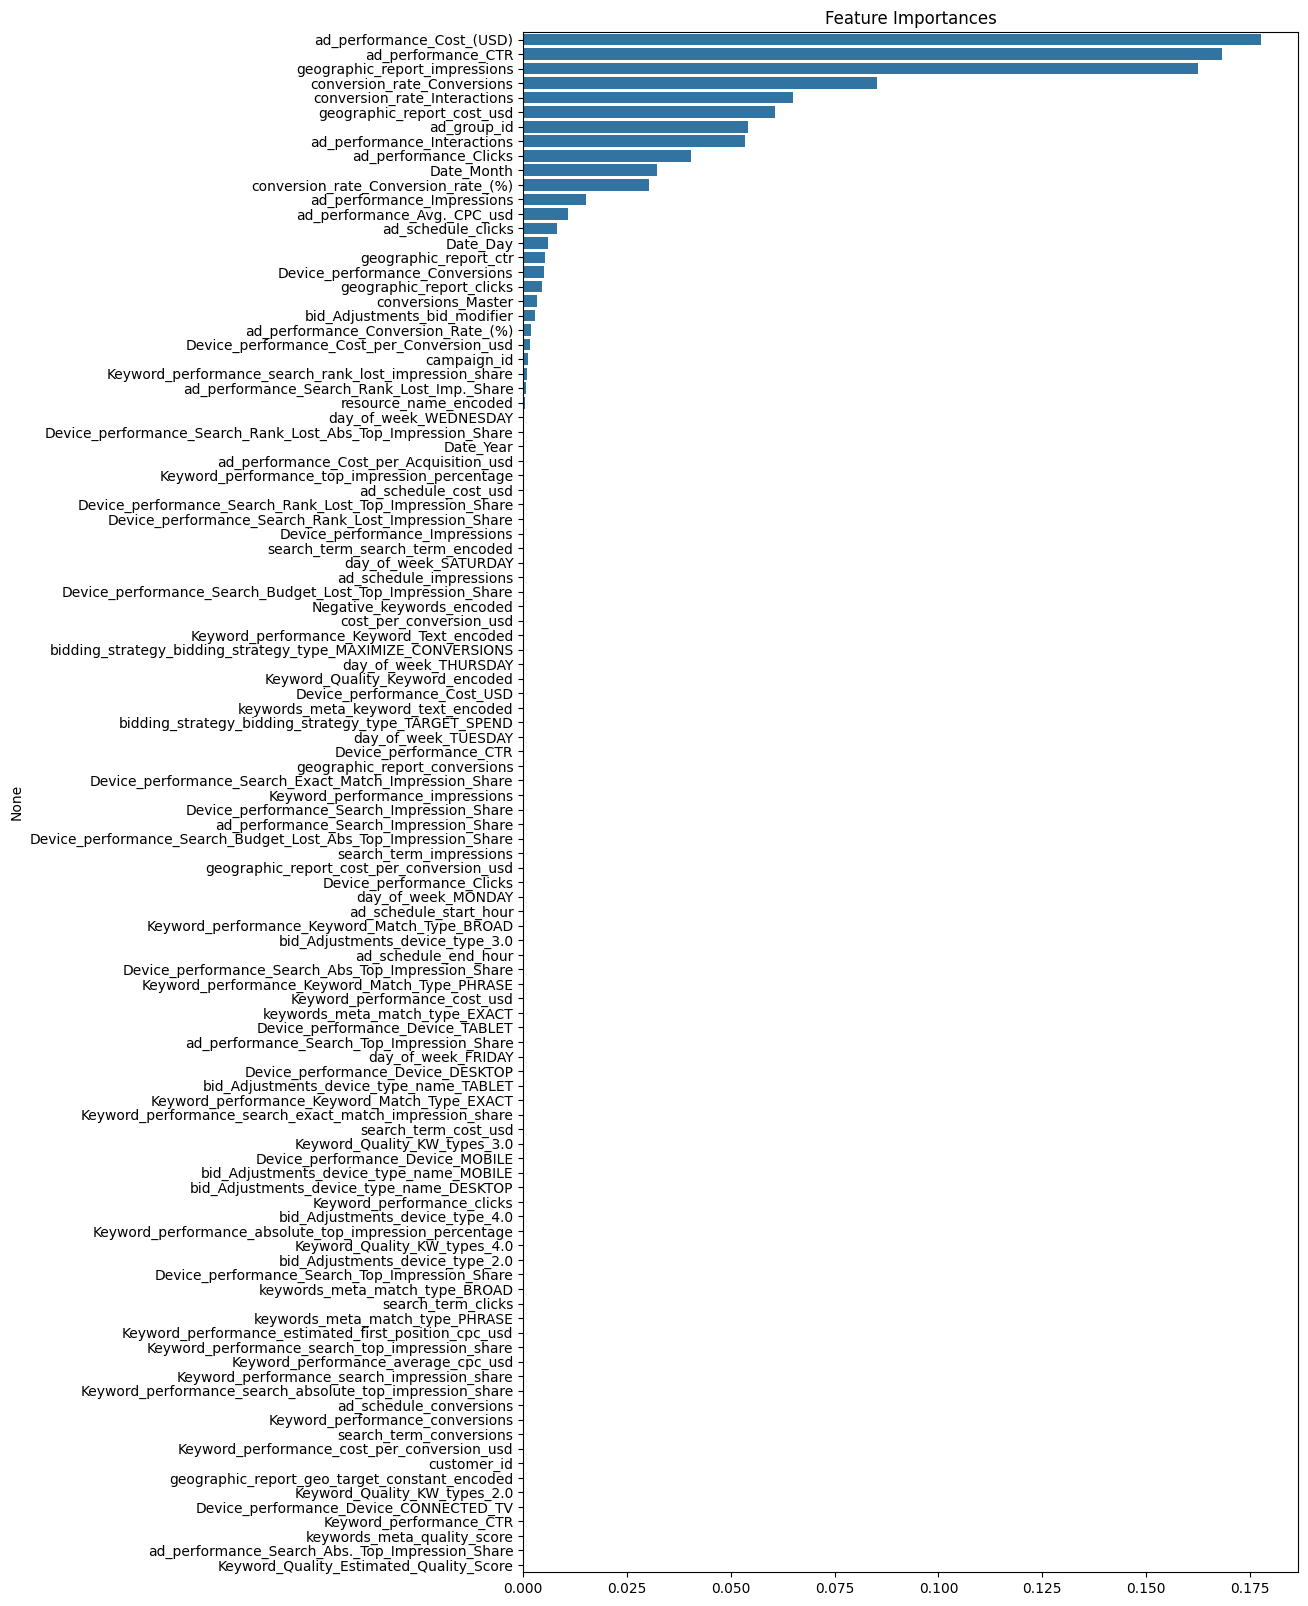

In [45]:

# --- Feature Importances Plot ---
os.makedirs("plots", exist_ok=True)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,20))
sns.barplot(x=importances[indices], y=X_train.columns[indices])
plt.title("Feature Importances")
plot_path = "plots/feature_importances.png"
plt.savefig(plot_path)

print("\n✅ Run completed with simple Random Forest model.")

impressions - RMSE: 0.1546, MAE: 0.0587, R2: 0.9709
clicks - RMSE: 0.1058, MAE: 0.0388, R2: 0.9620
cost_usd - RMSE: 0.1568, MAE: 0.0485, R2: 0.9931
ctr - RMSE: 0.0164, MAE: 0.0042, R2: 0.7788
average_cpc_usd - RMSE: 0.1497, MAE: 0.0469, R2: 0.9899
ad_performance_Conversions - RMSE: 0.2893, MAE: 0.0236, R2: 0.8521


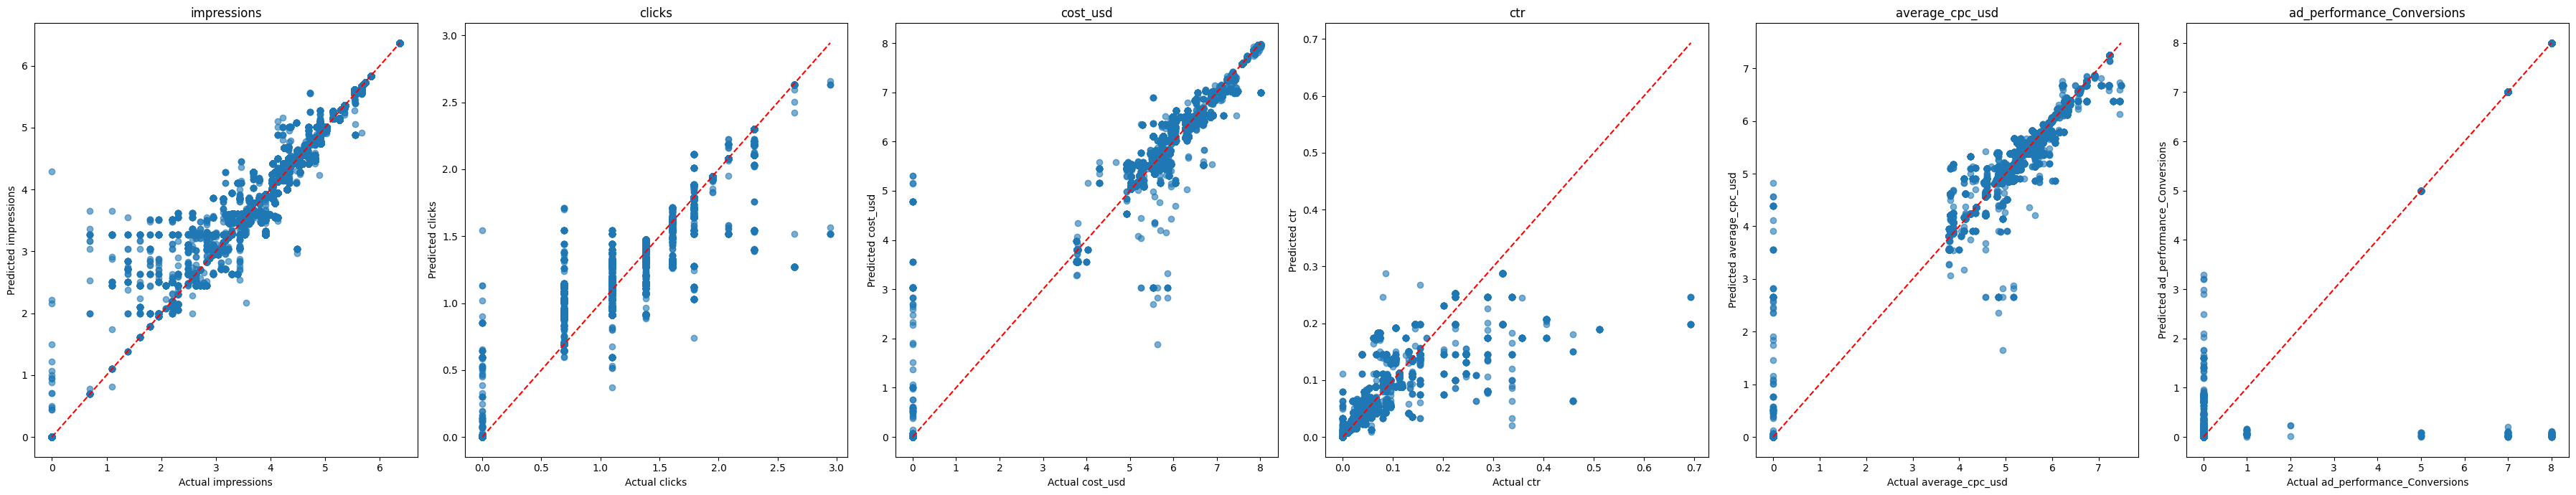

In [46]:

fig, axes = plt.subplots(1, len(target_columns), figsize=(6 * len(target_columns), 7))
for i, target in enumerate(target_columns):
    y_true = y_test[target].values
    y_pred_target = y_pred[:, i]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred_target))
    mae = mean_absolute_error(y_true, y_pred_target)
    r2 = r2_score(y_true, y_pred_target)

    print(f"{target} - RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

    ax = axes[i] if len(target_columns) > 1 else axes
    ax.scatter(y_true, y_pred_target, alpha=0.6)
    ax.set_xlabel(f"Actual {target}")
    ax.set_ylabel(f"Predicted {target}")
    ax.set_title(f"{target}")
    ax.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red', linestyle='--')
plt.tight_layout()
plt.show()


In [47]:
import joblib
import json

# --- Save model ---
model_path = "best_rf_multi_output.pkl"
joblib.dump(rf, model_path)
print(f"✅ Model saved to {model_path}")

# --- Save feature columns ---
columns_path = "feature_columns.json"
with open(columns_path, "w") as f:
    json.dump(list(X_train.columns), f)
print(f"✅ Feature columns saved to {columns_path}")

# --- (Optional) Save target columns too ---
target_columns_path = "target_columns.json"
with open(target_columns_path, "w") as f:
    json.dump(target_columns, f)
print(f"✅ Target columns saved to {target_columns_path}")


✅ Model saved to best_rf_multi_output.pkl
✅ Feature columns saved to feature_columns.json
✅ Target columns saved to target_columns.json


In [48]:
# --- Load model & columns ---
rf_loaded = joblib.load(model_path)

with open(columns_path, "r") as f:
    feature_columns = json.load(f)

with open(target_columns_path, "r") as f:
    target_columns_loaded = json.load(f)

# --- Take 10 samples from test data ---
sample_X = X_test.sample(10, random_state=42)  # pick 10 random rows
sample_y = y_test.loc[sample_X.index]          # matching actual targets

# --- Predict ---
preds = rf_loaded.predict(sample_X)

# --- Create DataFrame for comparison ---
comparison_df = pd.DataFrame(preds, columns=[f"pred_{t}" for t in target_columns_loaded])
comparison_df["index"] = sample_X.index
for t in target_columns_loaded:
    comparison_df[f"actual_{t}"] = sample_y[t].values

# Reorder columns: index, actuals, predictions
cols = ["index"]
for t in target_columns_loaded:
    cols += [f"actual_{t}", f"pred_{t}"]
comparison_df = comparison_df[cols]

print("\n🔍 Predictions vs Actuals (10 samples):")
print(comparison_df.to_string(index=False))



🔍 Predictions vs Actuals (10 samples):
 index  actual_impressions  pred_impressions  actual_clicks  pred_clicks  actual_cost_usd  pred_cost_usd  actual_ctr  pred_ctr  actual_average_cpc_usd  pred_average_cpc_usd  actual_ad_performance_Conversions  pred_ad_performance_Conversions
 31670               6.368             6.368          1.792        1.792            7.074          7.074       0.009     0.009                   5.468                 5.468                              0.000                            0.000
 67737               2.197             2.197          1.099        1.186            6.699          6.563       0.223     0.252                   6.007                 5.750                              0.000                            0.000
219883               6.368             6.368          1.792        1.792            7.074          7.074       0.009     0.009                   5.468                 5.468                              0.000                            0.

In [49]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import numpy as np
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# === CONFIG ===
LOG_TRANSFORMED = False  # True if y is np.log1p transformed
ENSEMBLE_WEIGHTS = (0.6, 0.4)  # (RF weight, XGB weight)

# Output folders
for folder in [
    "artifacts/models", 
    "artifacts/pred_vs_actual", 
    "artifacts/residual_plots",
    "artifacts/feature_importances",
    "artifacts/comparison_plots"
]:
    os.makedirs(folder, exist_ok=True)

metrics = {}

def inverse_if_needed(y):
    """Inverse transform if log-transformed."""
    return np.expm1(y) if LOG_TRANSFORMED else y

def evaluate(model_name, y_test_actual, y_pred_actual, target):
    """Return metrics and store them."""
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    r2 = r2_score(y_test_actual, y_pred_actual)
    metrics[f"{target}_{model_name}"] = {"RMSE": rmse, "MAE": mae, "R2": r2}

def plot_individual(model_name, y_test_actual, y_pred_actual, target):
    """Plot predicted vs actual and residual plots."""
    # Predicted vs Actual
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_test_actual, y=y_pred_actual, s=10, alpha=0.6)
    plt.plot([y_test_actual.min(), y_test_actual.max()],
             [y_test_actual.min(), y_test_actual.max()],
             'r--', label="Ideal")
    sns.regplot(x=y_test_actual, y=y_pred_actual, scatter=False,
                line_kws={"color": "blue" if "RandomForest" in model_name else
                                    "green" if "XGBoost" in model_name else "purple", "lw": 1},
                ci=None, label=f"{model_name} Trend")
    plt.xlabel(f"Actual {target}")
    plt.ylabel(f"Predicted {target}")
    plt.title(f"{target} - {model_name} Predicted vs Actual")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"artifacts/pred_vs_actual/{target}_{model_name}.png")
    plt.close()

    # Residual plot
    residuals = y_test_actual - y_pred_actual
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=y_test_actual, y=residuals, s=10, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--', lw=1)
    plt.xlabel(f"Actual {target}")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(f"{target} - {model_name} Residual Plot")
    plt.tight_layout()
    plt.savefig(f"artifacts/residual_plots/{target}_{model_name}.png")
    plt.close()

def plot_comparison(y_test_actual, preds_dict, target):
    """Plot multiple model predictions together."""
    plt.figure(figsize=(6, 6))
    colors = {"RandomForest": "blue", "XGBoost": "green", "Ensemble": "purple"}
    for name, preds in preds_dict.items():
        plt.scatter(y_test_actual, preds, s=10, alpha=0.5, label=f"{name} Predictions", color=colors[name])

    # Ideal line
    plt.plot([y_test_actual.min(), y_test_actual.max()],
             [y_test_actual.min(), y_test_actual.max()],
             'r--', label="Ideal")

    # Trend lines
    for name, preds in preds_dict.items():
        sns.regplot(x=y_test_actual, y=preds, scatter=False, color=colors[name], ci=None, label=f"{name} Trend")

    plt.xlabel(f"Actual {target}")
    plt.ylabel("Predicted")
    plt.title(f"{target} - RF vs XGB vs Ensemble Comparison")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"artifacts/comparison_plots/{target}_RF_XGB_Ensemble.png")
    plt.close()


# === MAIN LOOP ===
for target in target_columns:
    print(f"\n=== Training models for {target} ===")
    y_train_target = y_train[target]
    y_test_target = y_test[target]

    # RandomForest
    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train_target)
    joblib.dump(rf, f"artifacts/models/{target}_RandomForest.joblib")
    y_pred_rf_log = rf.predict(X_test)
    y_pred_rf_actual = inverse_if_needed(y_pred_rf_log)
    y_test_actual = inverse_if_needed(y_test_target)  # Same for all models
    evaluate("RandomForest", y_test_actual, y_pred_rf_actual, target)
    plot_individual("RandomForest", y_test_actual, y_pred_rf_actual, target)

    # XGBoost
    xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    xgb.fit(X_train, y_train_target)
    joblib.dump(xgb, f"artifacts/models/{target}_XGBoost.joblib")
    y_pred_xgb_log = xgb.predict(X_test)
    y_pred_xgb_actual = inverse_if_needed(y_pred_xgb_log)
    evaluate("XGBoost", y_test_actual, y_pred_xgb_actual, target)
    plot_individual("XGBoost", y_test_actual, y_pred_xgb_actual, target)

    # Ensemble (weighted average in log space)
    w_rf, w_xgb = ENSEMBLE_WEIGHTS
    ensemble_pred_log = w_rf * y_pred_rf_log + w_xgb * y_pred_xgb_log
    ensemble_pred_actual = inverse_if_needed(ensemble_pred_log)
    evaluate("Ensemble", y_test_actual, ensemble_pred_actual, target)
    plot_individual("Ensemble", y_test_actual, ensemble_pred_actual, target)

    # Comparison plot
    preds_dict = {
        "RandomForest": y_pred_rf_actual,
        "XGBoost": y_pred_xgb_actual,
        "Ensemble": ensemble_pred_actual
    }
    plot_comparison(y_test_actual, preds_dict, target)

# Save metrics
with open("artifacts/metrics_comparison.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("\n✅ Training complete. Check 'artifacts/comparison_plots' for RF, XGB, and Ensemble comparisons.")



=== Training models for impressions ===

=== Training models for clicks ===

=== Training models for cost_usd ===

=== Training models for ctr ===

=== Training models for average_cpc_usd ===

=== Training models for ad_performance_Conversions ===

✅ Training complete. Check 'artifacts/comparison_plots' for RF, XGB, and Ensemble comparisons.


In [51]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# === CONFIG ===
LOG_TRANSFORMED = False
TARGET_COLUMNS = target_columns  # already defined in your environment

# Output folders
for folder in [
    "artifacts3/models", 
    "artifacts3/pred_vs_actual", 
    "artifacts3/residual_plots",
    "artifacts3/comparison_plots"
]:
    os.makedirs(folder, exist_ok=True)

metrics = {}
best_weights = {}

def inverse_if_needed(y):
    """Inverse transform if log-transformed with overflow protection."""
    if LOG_TRANSFORMED:
        # Clip values to prevent overflow in expm1
        y = np.clip(y, -700, 700)
        return np.expm1(y)
    return y

def evaluate(model_name, y_test_actual, y_pred_actual, target):
    """Store metrics for a given target."""
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    r2 = r2_score(y_test_actual, y_pred_actual)
    metrics[f"{target}_{model_name}"] = {"RMSE": rmse, "MAE": mae, "R2": r2}

def plot_individual(model_name, y_test_actual, y_pred_actual, target):
    """Plot predicted vs actual and residuals for one target."""
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_test_actual, y=y_pred_actual, s=10, alpha=0.6)
    plt.plot([y_test_actual.min(), y_test_actual.max()],
             [y_test_actual.min(), y_test_actual.max()],
             'r--', label="Ideal")
    color_map = {"RandomForest": "blue", "XGBoost": "green", "Ensemble": "purple"}
    sns.regplot(x=y_test_actual, y=y_pred_actual, scatter=False,
                line_kws={"color": color_map.get(model_name, "black"), "lw": 1},
                ci=None, label=f"{model_name} Trend")
    plt.xlabel(f"Actual {target}")
    plt.ylabel(f"Predicted {target}")
    plt.title(f"{target} - {model_name} Predicted vs Actual")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"artifacts3/pred_vs_actual/{target}_{model_name}.png")
    plt.close()

    # Residuals
    residuals = y_test_actual - y_pred_actual
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=y_test_actual, y=residuals, s=10, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--', lw=1)
    plt.xlabel(f"Actual {target}")
    plt.ylabel("Residual")
    plt.title(f"{target} - {model_name} Residuals")
    plt.tight_layout()
    plt.savefig(f"artifacts3/residual_plots/{target}_{model_name}.png")
    plt.close()

def plot_comparison(y_test_actual, preds_dict, target):
    """Plot multiple model predictions for a target."""
    plt.figure(figsize=(6, 6))
    colors = {"RandomForest": "blue", "XGBoost": "green", "Ensemble": "purple"}
    for name, preds in preds_dict.items():
        plt.scatter(y_test_actual, preds, s=10, alpha=0.5, color=colors[name], label=f"{name} Predictions")

    plt.plot([y_test_actual.min(), y_test_actual.max()],
             [y_test_actual.min(), y_test_actual.max()],
             'r--', label="Ideal")

    for name, preds in preds_dict.items():
        sns.regplot(x=y_test_actual, y=preds, scatter=False, color=colors[name], ci=None, label=f"{name} Trend")

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{target} - Model Comparison")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"artifacts3/comparison_plots/{target}_comparison.png")
    plt.close()

def find_best_weight(y_true, pred_rf, pred_xgb):
    """Grid search for best weight minimizing RMSE."""
    best_w = 0.5
    best_rmse = float("inf")
    for w in np.linspace(0, 1, 21):  # 0.0 to 1.0 in steps of 0.05
        blended = w * pred_rf + (1 - w) * pred_xgb
        rmse = np.sqrt(mean_squared_error(y_true, inverse_if_needed(blended)))
        if rmse < best_rmse:
            best_rmse = rmse
            best_w = w
    return best_w

# === TRAIN MODELS ===
print("\n=== Training Multi-Output RandomForest ===")
rf_multi = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )
)
rf_multi.fit(X_train, y_train)
joblib.dump(rf_multi, "artifacts3/models/MultiOutput_RandomForest.joblib")

print("=== Training Multi-Output XGBoost ===")
xgb_multi = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
)
xgb_multi.fit(X_train, y_train)
joblib.dump(xgb_multi, "artifacts3/models/MultiOutput_XGBoost.joblib")

# Predictions in log space
y_pred_rf_log = rf_multi.predict(X_test)
y_pred_xgb_log = xgb_multi.predict(X_test)

# Actual target values (inverse transformed once)
y_test_actual_all = inverse_if_needed(y_test.values)
y_pred_rf_actual_all = inverse_if_needed(y_pred_rf_log)
y_pred_xgb_actual_all = inverse_if_needed(y_pred_xgb_log)

# === AUTO-TUNE ENSEMBLE PER TARGET ===
ensemble_pred_log_all = np.zeros_like(y_pred_rf_log)
for idx, target in enumerate(TARGET_COLUMNS):
    # Find best weight for this target
    best_w = find_best_weight(
        y_test_actual_all[:, idx],
        y_pred_rf_log[:, idx],
        y_pred_xgb_log[:, idx]
    )
    best_weights[target] = best_w

    # Blend in log space with best weight
    ensemble_pred_log_all[:, idx] = best_w * y_pred_rf_log[:, idx] + (1 - best_w) * y_pred_xgb_log[:, idx]

# Convert final ensemble to actual scale
ensemble_pred_actual_all = inverse_if_needed(ensemble_pred_log_all)

# === METRICS & PLOTS PER TARGET ===
for idx, target in enumerate(TARGET_COLUMNS):
    # Evaluate all three
    evaluate("RandomForest", y_test_actual_all[:, idx], y_pred_rf_actual_all[:, idx], target)
    evaluate("XGBoost", y_test_actual_all[:, idx], y_pred_xgb_actual_all[:, idx], target)
    evaluate("Ensemble", y_test_actual_all[:, idx], ensemble_pred_actual_all[:, idx], target)

    # Plots
    plot_individual("RandomForest", y_test_actual_all[:, idx], y_pred_rf_actual_all[:, idx], target)
    plot_individual("XGBoost", y_test_actual_all[:, idx], y_pred_xgb_actual_all[:, idx], target)
    plot_individual("Ensemble", y_test_actual_all[:, idx], ensemble_pred_actual_all[:, idx], target)

    preds_dict = {
        "RandomForest": y_pred_rf_actual_all[:, idx],
        "XGBoost": y_pred_xgb_actual_all[:, idx],
        "Ensemble": ensemble_pred_actual_all[:, idx]
    }
    plot_comparison(y_test_actual_all[:, idx], preds_dict, target)

# Save metrics & best weights
with open("artifacts3/metrics_multioutput.json", "w") as f:
    json.dump(metrics, f, indent=4)

with open("artifacts3/best_weights.json", "w") as f:
    json.dump(best_weights, f, indent=4)

print("\n✅ Multi-output training complete.")
print("Best weights per target saved to 'artifacts3/best_weights.json'")



=== Training Multi-Output RandomForest ===
=== Training Multi-Output XGBoost ===

✅ Multi-output training complete.
Best weights per target saved to 'artifacts3/best_weights.json'


In [155]:
# === PLOT BEST WEIGHTS PER TARGET ===
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
targets = list(best_weights.keys())
rf_weights = [best_weights[t] for t in targets]
xgb_weights = [1 - best_weights[t] for t in targets]

bar_width = 0.35
x = np.arange(len(targets))

plt.bar(x, rf_weights, bar_width, label="RandomForest", color="skyblue")
plt.bar(x, xgb_weights, bar_width, bottom=rf_weights, label="XGBoost", color="lightgreen")

plt.xticks(x, targets, rotation=30, ha="right")
plt.ylabel("Ensemble Weight")
plt.title("Optimal Ensemble Weights per Target")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig("artifacts3/ensemble_weights_per_target.png")
plt.close()

print("📊 Ensemble weight chart saved to artifacts3/ensemble_weights_per_target.png")


📊 Ensemble weight chart saved to artifacts3/ensemble_weights_per_target.png


In [156]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Select 10 random examples from test data ---
sample_idx = np.random.choice(len(X_test), size=10, replace=False)
X_sample = X_test.iloc[sample_idx]
y_sample = y_test.iloc[sample_idx]

# --- Predict using final ensemble ---
rf_preds = rf_multi.predict(X_sample)
xgb_preds = xgb_multi.predict(X_sample)

# Inverse transform if log1p used
if LOG_TRANSFORMED:
    rf_preds = np.expm1(rf_preds)
    xgb_preds = np.expm1(xgb_preds)
    y_sample_actual = np.expm1(y_sample)
else:
    y_sample_actual = y_sample

# Ensemble combine with best weights
ensemble_preds = np.zeros_like(rf_preds)
for i, target in enumerate(target_columns):
    w_rf = best_weights[target]
    w_xgb = 1 - w_rf
    ensemble_preds[:, i] = w_rf * rf_preds[:, i] + w_xgb * xgb_preds[:, i]

# --- Create nicely aligned DataFrame ---
aligned_data = []
for row_idx in range(len(X_sample)):
    row = {}
    for i, target in enumerate(target_columns):
        row[f"{target} (Actual)"] = y_sample_actual.iloc[row_idx, i]
        row[f"{target} (Predicted)"] = ensemble_preds[row_idx, i]
    aligned_data.append(row)

results_df = pd.DataFrame(aligned_data)

# Print table
print("🔍 Predictions vs Actuals (10 samples):")
print(results_df.to_string(index=False))

# Save to CSV
results_df.to_csv("artifacts3/sample_predictions_aligned.csv", index=False)
print("📁 Saved to artifacts3/sample_predictions_aligned.csv")

# --- Plot comparison ---
plt.figure(figsize=(15, 10))
for i, target in enumerate(target_columns):
    plt.subplot(3, 3, i+1)  # grid of 3x2 for up to 5 targets
    plt.plot(range(len(X_sample)), y_sample_actual.iloc[:, i], label="Actual", marker="o")
    plt.plot(range(len(X_sample)), ensemble_preds[:, i], label="Predicted", marker="x")
    plt.title(f"Actual vs Predicted - {target}")
    plt.xlabel("Sample Index")
    plt.ylabel(target)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.savefig("artifacts3/sample_predictions_plot.png")
plt.close()
print("📊 Plot saved to artifacts3/sample_predictions_plot.png")


🔍 Predictions vs Actuals (10 samples):
 impressions (Actual)  impressions (Predicted)  clicks (Actual)  clicks (Predicted)  cost_usd (Actual)  cost_usd (Predicted)  ctr (Actual)  ctr (Predicted)  average_cpc_usd (Actual)  average_cpc_usd (Predicted)  ad_performance_Conversions (Actual)  ad_performance_Conversions (Predicted)
              100.000                  100.288            4.000               4.000           1589.760              1589.760         0.040            0.039                   397.440                      396.104                                0.000                                   0.062
              152.000                  151.973            3.000               3.000           1541.540              1541.540         0.020            0.020                   513.847                      513.580                                0.000                                   0.001
                8.000                    8.029            0.000               0.000              

In [158]:
import joblib
import os

os.makedirs("artifacts", exist_ok=True)

# Save models
joblib.dump(rf_multi, "artifacts3/models/rf_multi_model.pkl")
joblib.dump(xgb_multi, "artifacts3/models/xgb_multi_model.pkl")

# Save weights
joblib.dump(best_weights, "artifacts3/models/ensemble_weights.pkl")

print("✅ Ensemble components saved in 'artifacts3/models/' folder")


✅ Ensemble components saved in 'artifacts3/models/' folder


In [160]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Load models & weights ---
rf_multi_loaded = joblib.load("artifacts3/models/rf_multi_model.pkl")
xgb_multi_loaded = joblib.load("artifacts3/models/xgb_multi_model.pkl")
best_weights_loaded = joblib.load("artifacts3/models/ensemble_weights.pkl")

# --- Select the same 10 examples from test data ---
# If you want EXACT same examples, you must have saved 'sample_idx' earlier.
# Here we assume we re-select random ones
sample_idx = np.random.choice(len(X_test), size=100, replace=False)
X_sample = X_test.iloc[sample_idx]
y_sample = y_test.iloc[sample_idx]

# --- Predict with both models ---
rf_preds = rf_multi_loaded.predict(X_sample)
xgb_preds = xgb_multi_loaded.predict(X_sample)

# Inverse transform if log1p used
if LOG_TRANSFORMED:
    rf_preds = np.expm1(rf_preds)
    xgb_preds = np.expm1(xgb_preds)
    y_sample_actual = np.expm1(y_sample)
else:
    y_sample_actual = y_sample

# --- Combine predictions using stored weights ---
ensemble_preds = np.zeros_like(rf_preds)
for i, target in enumerate(target_columns):
    w_rf = best_weights_loaded[target]
    w_xgb = 1 - w_rf
    ensemble_preds[:, i] = w_rf * rf_preds[:, i] + w_xgb * xgb_preds[:, i]

# --- Build results DataFrame ---
aligned_data = []
for row_idx in range(len(X_sample)):
    row = {}
    for i, target in enumerate(target_columns):
        row[f"{target} (Actual)"] = y_sample_actual.iloc[row_idx, i]
        row[f"{target} (Predicted)"] = ensemble_preds[row_idx, i]
    aligned_data.append(row)

results_df = pd.DataFrame(aligned_data)

# Print results
print("🔍 Predictions vs Actuals (10 samples):")
print(results_df.to_string(index=False))

# Save to CSV
results_df.to_csv("artifacts3/sample_predictions_from_loaded_models.csv", index=False)
print("📁 Saved to artifacts3/sample_predictions_from_loaded_models.csv")

# --- Plot comparison ---
plt.figure(figsize=(15, 10))
for i, target in enumerate(target_columns):
    plt.subplot(3, 3, i+1)
    plt.plot(range(len(X_sample)), y_sample_actual.iloc[:, i], label="Actual", marker="o")
    plt.plot(range(len(X_sample)), ensemble_preds[:, i], label="Predicted", marker="x")
    plt.title(f"Actual vs Predicted - {target}")
    plt.xlabel("Sample Index")
    plt.ylabel(target)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.savefig("artifacts3/sample_predictions_plot_from_loaded_models.png")
plt.close()
print("📊 Plot saved to artifacts3/sample_predictions_plot_from_loaded_models.png")



🔍 Predictions vs Actuals (10 samples):
 impressions (Actual)  impressions (Predicted)  clicks (Actual)  clicks (Predicted)  cost_usd (Actual)  cost_usd (Predicted)  ctr (Actual)  ctr (Predicted)  average_cpc_usd (Actual)  average_cpc_usd (Predicted)  ad_performance_Conversions (Actual)  ad_performance_Conversions (Predicted)
              210.000                  209.984            6.000               6.000           2649.145              2649.145         0.029            0.029                   441.524                      441.375                                0.000                                   0.001
              582.000                  581.878            5.000               5.000           1179.670              1179.670         0.009            0.009                   235.934                      235.900                                0.000                                   0.001
              210.000                  209.984            6.000               6.000           264

In [161]:
X_sample


,conversions_Master,cost_per_conversion_usd,Keyword_Quality_Estimated_Quality_Score,conversion_rate_Interactions,conversion_rate_Conversions,conversion_rate_Conversion_rate_(%),ad_performance_Impressions,ad_performance_Clicks,ad_performance_Cost_(USD),ad_performance_CTR,ad_performance_Avg._CPC_usd,ad_performance_Cost_per_Acquisition_usd,ad_performance_Interactions,ad_performance_Conversion_Rate_(%),ad_performance_Search_Abs._Top_Impression_Share,ad_performance_Search_Top_Impression_Share,ad_performance_Search_Impression_Share,ad_performance_Search_Rank_Lost_Imp._Share,Device_performance_Impressions,Device_performance_Clicks,Device_performance_CTR,Device_performance_Cost_USD,Device_performance_Conversions,Device_performance_Cost_per_Conversion_usd,Device_performance_Search_Abs_Top_Impression_Share,Device_performance_Search_Budget_Lost_Abs_Top_Impression_Share,Device_performance_Search_Budget_Lost_Top_Impression_Share,Device_performance_Search_Top_Impression_Share,Device_performance_Search_Rank_Lost_Impression_Share,Device_performance_Search_Rank_Lost_Abs_Top_Impression_Share,Device_performance_Search_Rank_Lost_Top_Impression_Share,Device_performance_Search_Impression_Share,Device_performance_Search_Exact_Match_Impression_Share,Keyword_performance_impressions,Keyword_performance_clicks,Keyword_performance_CTR,Keyword_performance_average_cpc_usd,Keyword_performance_conversions,Keyword_performance_cost_usd,Keyword_performance_cost_per_conversion_usd,Keyword_performance_search_impression_share,Keyword_performance_search_top_impression_share,Keyword_performance_search_absolute_top_impression_share,Keyword_performance_search_rank_lost_impression_share,Keyword_performance_absolute_top_impression_percentage,Keyword_performance_top_impression_percentage,Keyword_performance_estimated_first_position_cpc_usd,Keyword_performance_search_exact_match_impression_share,bid_Adjustments_bid_modifier,ad_schedule_start_hour,ad_schedule_end_hour,ad_schedule_impressions,ad_schedule_clicks,ad_schedule_cost_usd,ad_schedule_conversions,keywords_meta_quality_score,search_term_impressions,search_term_clicks,search_term_cost_usd,search_term_conversions,geographic_report_impressions,geographic_report_clicks,geographic_report_ctr,geographic_report_cost_usd,geographic_report_conversions,geographic_report_cost_per_conversion_usd,campaign_id,ad_group_id,Date_Year,Date_Month,Date_Day,Keyword_Quality_Keyword_encoded,Keyword_performance_Keyword_Text_encoded,resource_name_encoded,keywords_meta_keyword_text_encoded,search_term_search_term_encoded,Negative_keywords_encoded,geographic_report_geo_target_constant_encoded,Keyword_Quality_KW_types_2.0,Keyword_Quality_KW_types_3.0,Keyword_Quality_KW_types_4.0,Device_performance_Device_CONNECTED_TV,Device_performance_Device_DESKTOP,Device_performance_Device_MOBILE,Device_performance_Device_TABLET,Keyword_performance_Keyword_Match_Type_BROAD,Keyword_performance_Keyword_Match_Type_EXACT,Keyword_performance_Keyword_Match_Type_PHRASE,bid_Adjustments_device_type_2.0,bid_Adjustments_device_type_3.0,bid_Adjustments_device_type_4.0,bid_Adjustments_device_type_6.0,bid_Adjustments_device_type_name_CONNECTED_TV,bid_Adjustments_device_type_name_DESKTOP,bid_Adjustments_device_type_name_MOBILE,bid_Adjustments_device_type_name_TABLET,day_of_week_FRIDAY,day_of_week_MONDAY,day_of_week_SATURDAY,day_of_week_THURSDAY,day_of_week_TUESDAY,day_of_week_WEDNESDAY,keywords_meta_match_type_BROAD,keywords_meta_match_type_EXACT,keywords_meta_match_type_PHRASE,bidding_strategy_bidding_strategy_type_MAXIMIZE_CONVERSIONS,bidding_strategy_bidding_strategy_type_TARGET_SPEND
365740,0.000,0.000,0.000,6.000,0.000,0.000,210.000,6.000,2649.145,0.029,441.524,0.000,6.000,0.000,0.100,0.100,0.100,0.900,162.000,4.000,0.025,1516.455,0.000,0.000,0.100,0.069,0.069,0.100,0.900,0.900,0.900,0.100,0.100,66.000,1.000,0.015,225.950,0.000,225.950,0.000,0.100,0.100,0.100,0.896,0.061,0.439,22.572,0.100,0.000,0.000,9.000,179.000,6.000,2649.145,0.000,0.000,1.000,0.000,0.000,0.000,2